In [251]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
import warnings
import importlib
from IPython.display import Image, display

import data_loader
importlib.reload(data_loader)
from data_loader import EEGDataLoader, get_default_data_path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [252]:
import pickle

with open('results/real_features.pkl', 'rb') as f:
    real_features = pickle.load(f)

print("Loaded extracted features from results/real_features.pkl")
print(f"Available features: {list(real_features.keys())}")

Loaded extracted features from results/real_features.pkl
Available features: ['p300', 'theta', 'alpha', 'beta', 'gamma', 'response_time']


# Exploratory Data Analysis

## Load Data

In [253]:
data_path = get_default_data_path()
print(f"Data path: {data_path}")
loader = EEGDataLoader(str(data_path))

Data path: c:\Users\kamil\Documents\github\neuron\lie-detector\DATA\lie-detector
Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants


In [254]:
summary_df = loader.create_summary_dataframe()
print(f"Total participants: {len(summary_df)}\n")
display(summary_df)

Total participants: 15



,participant_id,n_files,sex,age,honest_true,deceitful_true,honest_fake,deceitful_fake
0,02F6BC66,4,M,22,True,True,True,True
1,1299BF1A,4,K,23,True,True,True,True
2,2D663E30,4,M,22,True,True,True,True
3,4C0F44CF,4,M,25,True,True,True,True
4,827366EC,4,M,22,True,True,True,True
5,8DB745E3,4,K,19,True,True,True,True
6,A3627947,4,K,22,True,True,True,True
7,ASD6DSA7,4,K,21,True,True,True,True
8,BNFH348D,4,K,21,True,True,True,True
9,DAF24E45,4,M,26,True,True,True,True


In [255]:
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
completeness = summary_df[block_columns].sum()

print("Block availability:")
for block, count in completeness.items():
    percentage = (count / len(summary_df)) * 100
    print(f"  {block}: {count}/{len(summary_df)} ({percentage:.1f}%)")

complete_participants = summary_df[summary_df[block_columns].all(axis=1)]
print(f"\nParticipants with all 4 blocks: {len(complete_participants)}")

Block availability:
  honest_true: 15/15 (100.0%)
  deceitful_true: 15/15 (100.0%)
  honest_fake: 15/15 (100.0%)
  deceitful_fake: 15/15 (100.0%)

Participants with all 4 blocks: 15


## Inspect Single Participant Data

In [256]:
if len(complete_participants) > 0:
    example_participant = complete_participants.iloc[0]['participant_id']
else:
    example_participant = loader.participants[0]

print(f"Loading data for participant: {example_participant}")
participant_data = loader.load_participant_data(example_participant)

Loading data for participant: 02F6BC66
  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz


In [257]:
first_block = list(participant_data.keys())[0]
raw = participant_data[first_block]

print(f"Recording Info - {first_block}")
print(f"  Sampling frequency: {raw.info['sfreq']} Hz")
print(f"  Number of channels: {len(raw.ch_names)}")
print(f"  Channel names: {raw.ch_names}")
print(f"  Duration: {raw.times[-1]:.2f} seconds")
print(f"  Total samples: {raw.n_times}")

Recording Info - honest_true
  Sampling frequency: 250.0 Hz
  Number of channels: 21
  Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'T3', 'T4', 'T5', 'T6', 'F7', 'F8', 'Accel_x', 'Accel_y', 'Accel_z', 'Digital', 'Sample']
  Duration: 298.30 seconds
  Total samples: 74575


In [258]:
events, event_id = loader.get_events_from_raw(raw)

print(f"\nEvent Information:")
print(f"  Total events: {len(events)}")
print(f"  Event types: {len(event_id)}")
print(f"\nEvent types and counts:")

event_counts = pd.Series([sum(events[:, 2] == id_) for id_ in event_id.values()],
                        index=event_id.keys())
display(event_counts)


Event Information:
  Total events: 216
  Event types: 11

Event types and counts:


ParticipantResponse.NO                                      54
ParticipantResponse.YES                                     54
PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY     3
PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO        18
PersonalDataField.BIRTH_DATE: PersonalDataType.REAL         15
PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY       3
PersonalDataField.HOMETOWN: PersonalDataType.RANDO          18
PersonalDataField.HOMETOWN: PersonalDataType.REAL           15
PersonalDataField.NAME: PersonalDataType.CELEBRITY           3
PersonalDataField.NAME: PersonalDataType.RANDO              18
PersonalDataField.NAME: PersonalDataType.REAL               15
dtype: int64

## Visualize Raw Signals

In [259]:
raw_filtered = raw.copy()
raw_filtered = raw_filtered.pick_types(eeg=True, stim=False, eog=False, exclude="bads")
raw_filtered.apply_function(lambda x: x * 10 ** -6)
raw_filtered.filter(l_freq=1.0, h_freq=50.0, verbose=False)
raw_filtered.notch_filter(freqs=[50, 100], verbose=False)

events_for_plot, event_id_plot = loader.get_events_from_raw(raw_filtered)
stimulus_event_ids = {k: v for k, v in event_id_plot.items() if 'PersonalDataField' in k}

epochs_plot = mne.Epochs(
    raw_filtered,
    events_for_plot,
    stimulus_event_ids,
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0),
    reject=dict(eeg=150e-6),
    preload=True,
    verbose=False
)

print(f"Created {len(epochs_plot)} epochs from {len(stimulus_event_ids)} stimulus types")

fig1 = epochs_plot.plot(
    n_epochs=20,
    n_channels=16,
    scalings=dict(eeg=50e-6),
    title=f'{example_participant} - {first_block} (Clean Epochs)',
    show=False,
    block=True
)
fig1.set_size_inches(16, 10)

evoked = epochs_plot.average()
fig2 = evoked.plot(
    spatial_colors=True,
    gfp=True,
    show=False,
    window_title=f'{example_participant} - Averaged Evoked Response'
)
fig2.set_size_inches(14, 8)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Created 81 epochs from 9 stimulus types
Created 81 epochs from 9 stimulus types


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


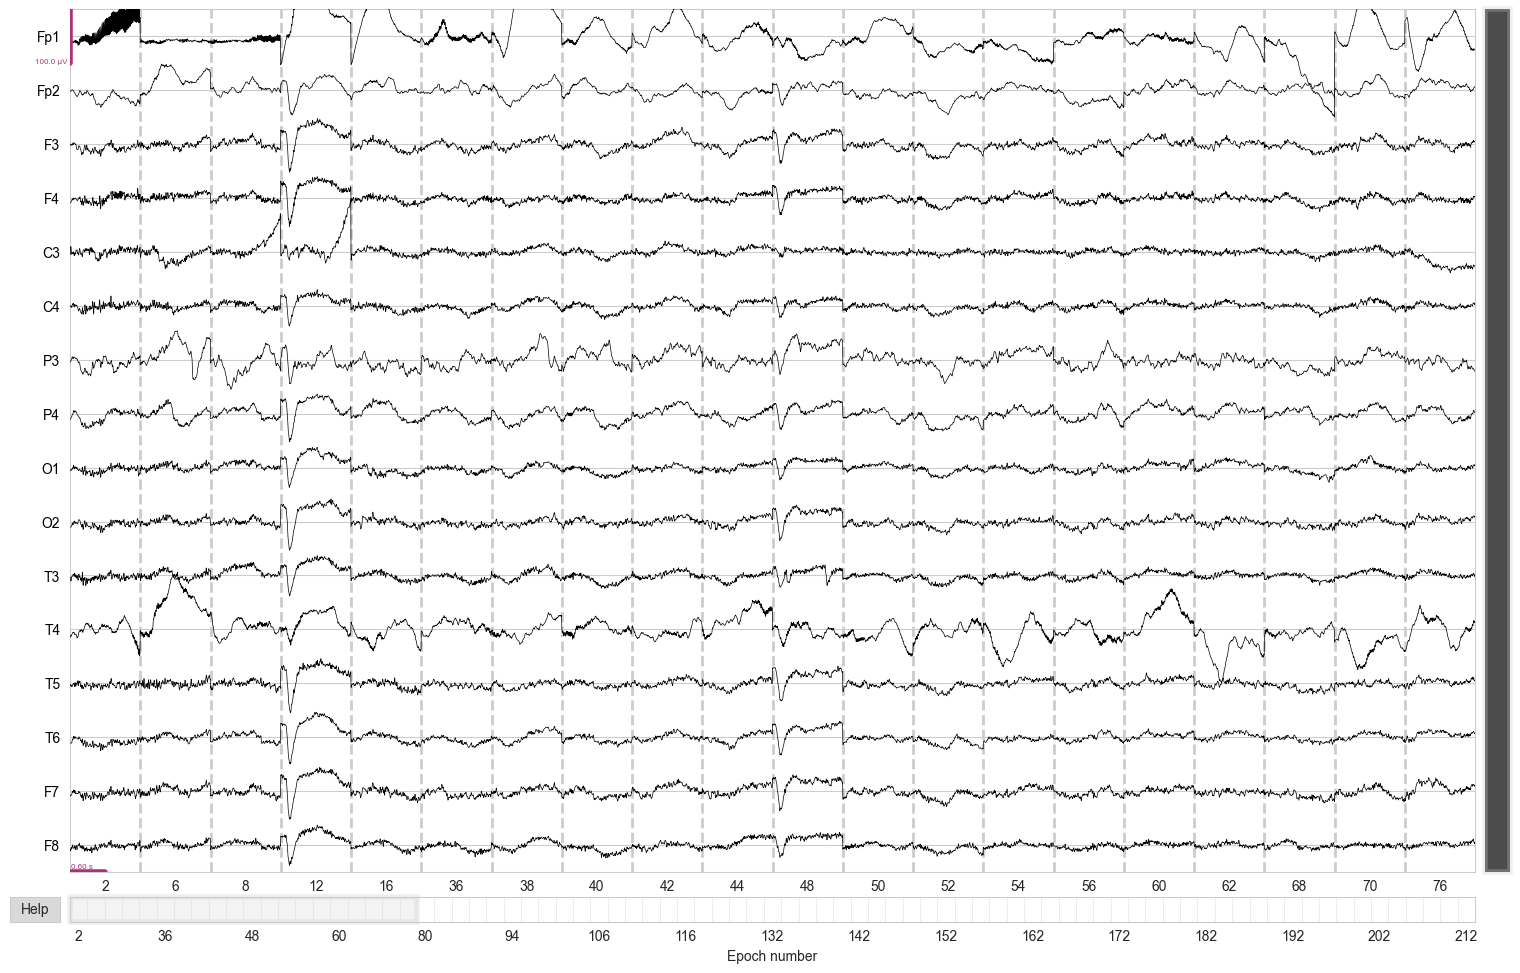

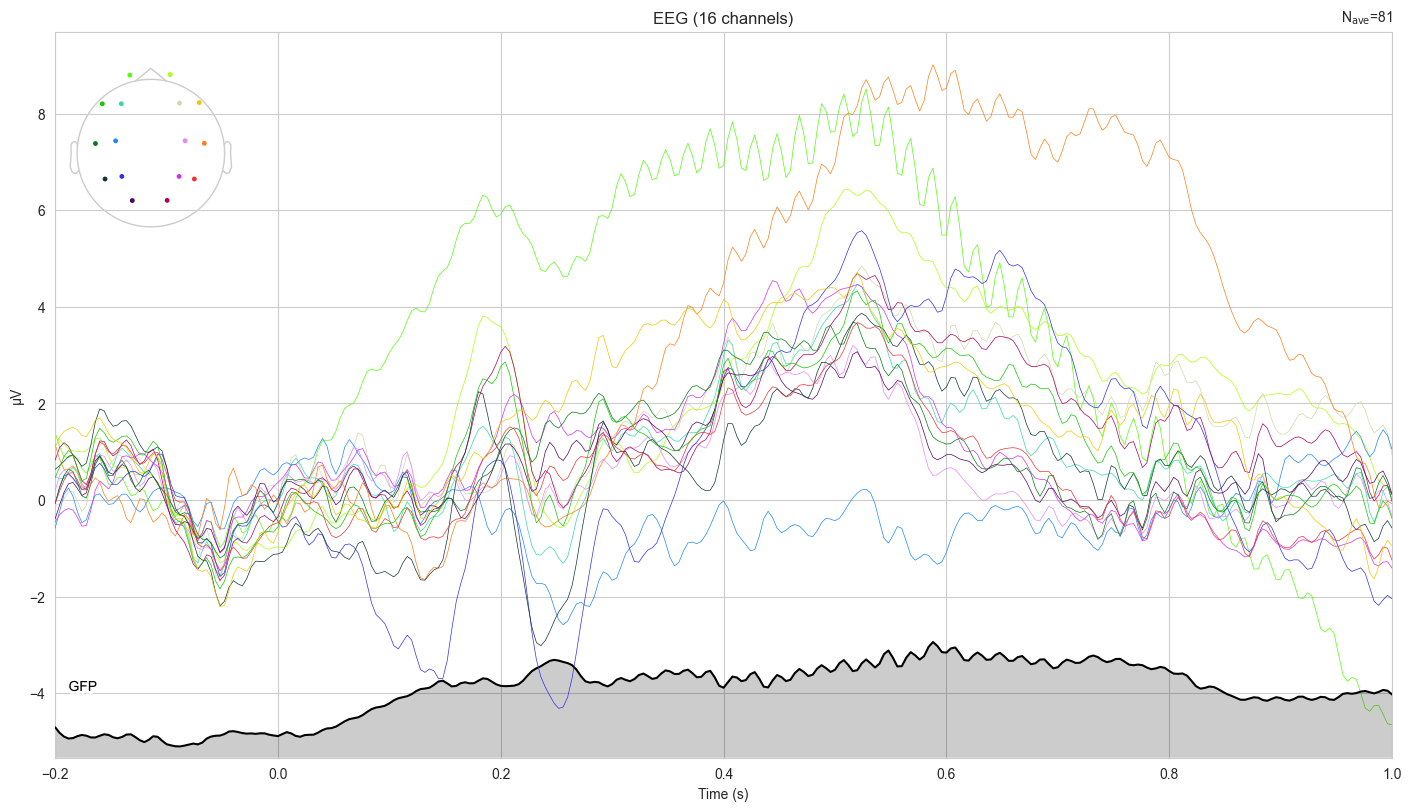

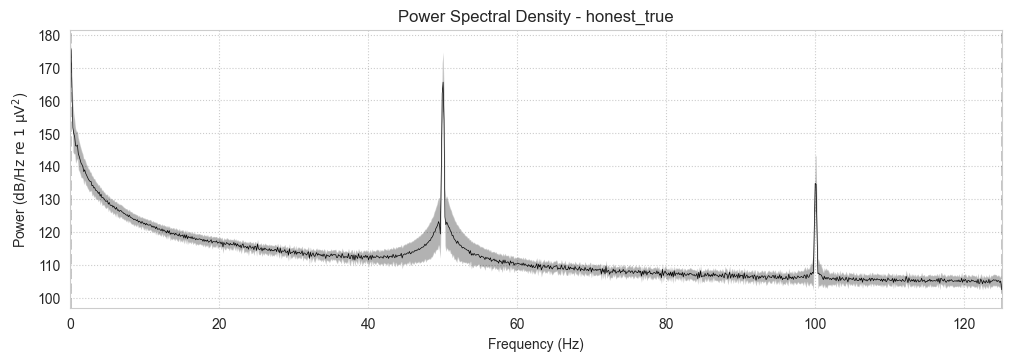

In [260]:
fig = raw.compute_psd(fmax=125).plot(average=True, amplitude=False, 
                                     picks='eeg', show=False)
plt.title(f'Power Spectral Density - {first_block}')
plt.savefig('charts/eda_power_spectral_density.png', dpi=300, bbox_inches='tight')
plt.show()


Auxiliary channels found: ['Accel_x', 'Accel_y', 'Accel_z']
Created 108 epochs for auxiliary channels


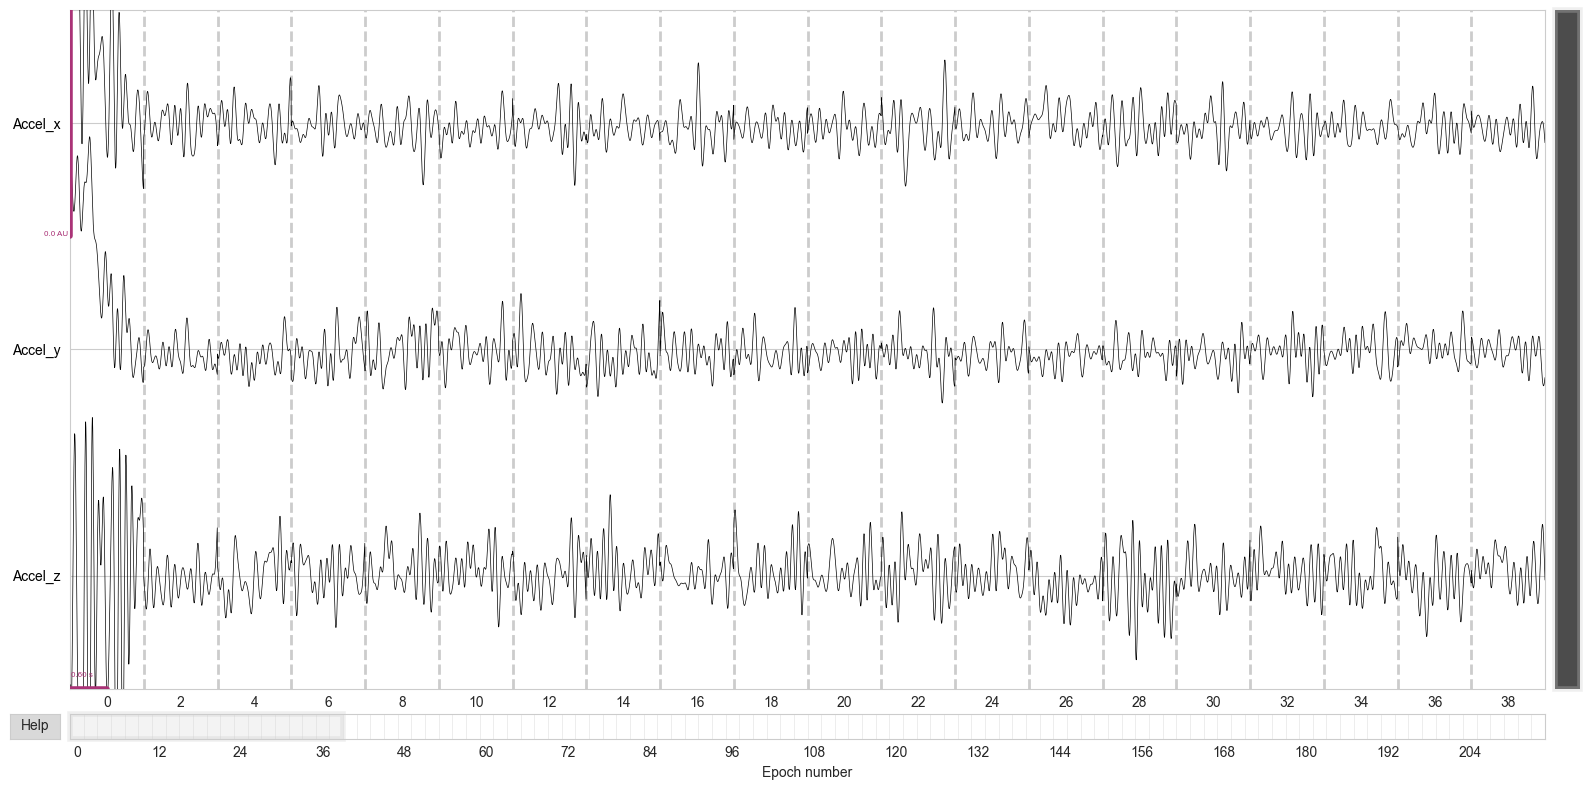

In [261]:
aux_raw = raw.copy()
aux_channels = [ch for ch in aux_raw.ch_names if 'Accel' in ch]

if aux_channels:
    print(f"Auxiliary channels found: {aux_channels}")
    
    aux_filtered = aux_raw.copy().pick(aux_channels)
    aux_filtered.load_data()
    aux_filtered.apply_function(lambda x: x * 10 ** -6, picks=aux_channels)
    aux_filtered.filter(l_freq=0.5, h_freq=10.0, picks=aux_channels, verbose=False)
    
    events_aux, event_id_aux = loader.get_events_from_raw(aux_filtered)
    stimulus_event_ids_aux = {k: v for k, v in event_id_aux.items() if 'PersonalDataField' in k}
    
    epochs_aux = mne.Epochs(
        aux_filtered,
        events_aux,
        stimulus_event_ids_aux,
        tmin=-0.2,
        tmax=1.0,
        baseline=(-0.2, 0),
        reject=None,
        preload=True,
        verbose=False
    )
    
    print(f"Created {len(epochs_aux)} epochs for auxiliary channels")
    
    epoch_data = epochs_aux.get_data()
    data_range = np.max(np.abs(epoch_data))
    scaling_value = data_range / 2.5
    
    fig_aux = epochs_aux.plot(
        picks=aux_channels,
        n_epochs=20,
        n_channels=len(aux_channels),
        scalings=dict(misc=scaling_value),
        title=f'{example_participant} - {first_block} (Auxiliary Channels: Motion)',
        show=False,
        block=True
    )
    fig_aux.set_size_inches(16, 8)
    plt.tight_layout()
    plt.savefig('charts/eda_aux_channels.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No auxiliary channels found in the data")


## Compare Across All Blocks

In [262]:
block_info = []

for block_name, raw_data in participant_data.items():
    events, event_id = loader.get_events_from_raw(raw_data)
    
    block_info.append({
        'block': block_name,
        'duration_sec': raw_data.times[-1],
        'n_events': len(events),
        'n_event_types': len(event_id),
        'sfreq': raw_data.info['sfreq']
    })

block_comparison = pd.DataFrame(block_info)
display(block_comparison)

,block,duration_sec,n_events,n_event_types,sfreq
0,honest_true,298.296,216,11,250.0
1,deceitful_true,329.096,222,12,250.0
2,honest_fake,318.096,218,12,250.0
3,deceitful_fake,314.496,216,11,250.0


## Signal Quality Assessment

In [263]:
data = raw.get_data() * 1e6

print("Signal Amplitude Statistics (in µV):")
print(f"  Mean: {np.mean(data):.2f} µV")
print(f"  Std: {np.std(data):.2f} µV")
print(f"  Min: {np.min(data):.2f} µV")
print(f"  Max: {np.max(data):.2f} µV")
print(f"  Range: {np.ptp(data):.2f} µV")

Signal Amplitude Statistics (in µV):
  Mean: 101773145537.20 µV
  Std: 72531191394.09 µV
  Min: -841410.58 µV
  Max: 280700348317.62 µV
  Range: 280701189728.20 µV


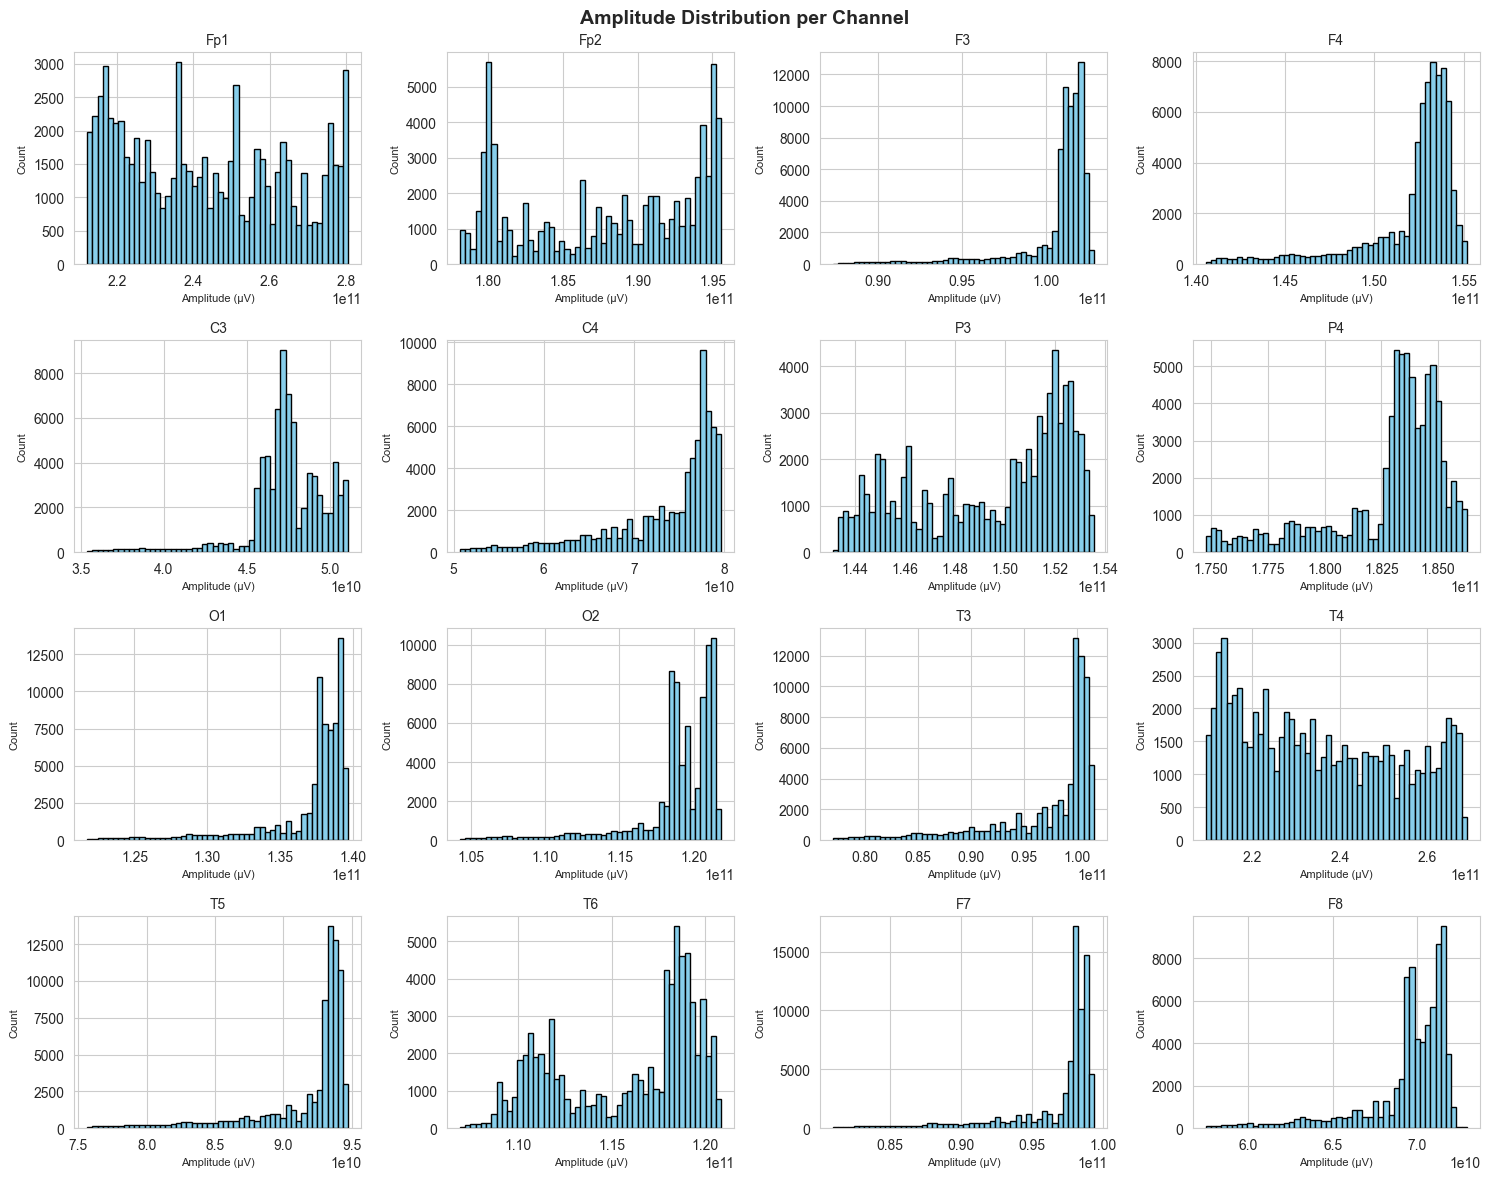

In [264]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for idx, ch_name in enumerate(raw.ch_names):
    if idx < len(axes):
        ch_data = data[idx, :]
        axes[idx].hist(ch_data, bins=50, color='skyblue', edgecolor='black')
        axes[idx].set_title(ch_name, fontsize=10)
        axes[idx].set_xlabel('Amplitude (µV)', fontsize=8)
        axes[idx].set_ylabel('Count', fontsize=8)

for idx in range(len(raw.ch_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Amplitude Distribution per Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/eda_amplitude_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Response Time Analysis

## P300 Analysis

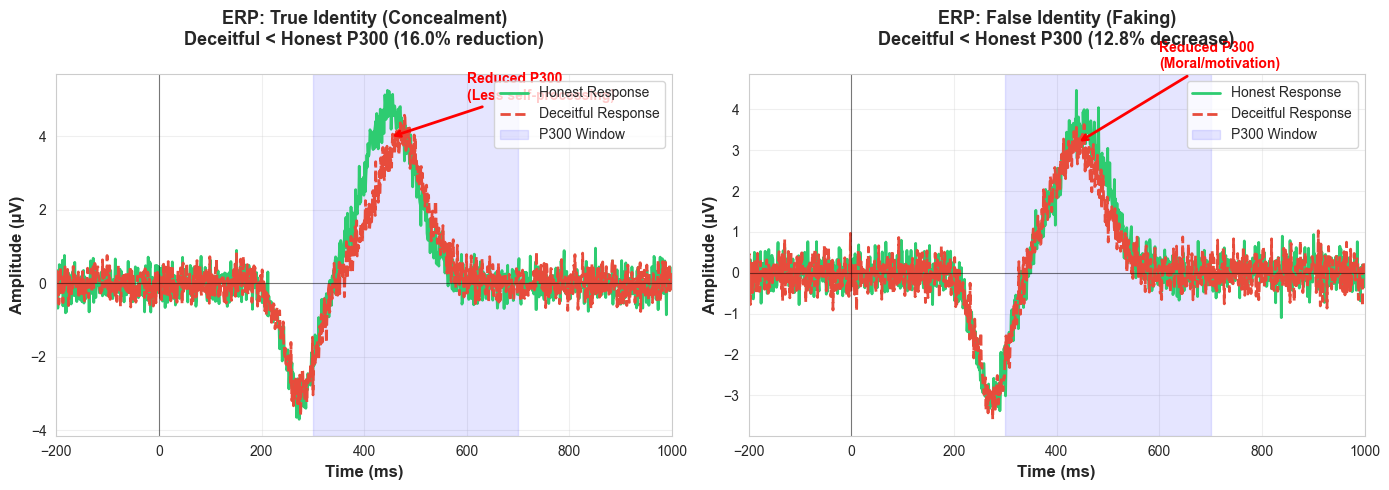

P300 Findings:
TRUE IDENTITY (Concealment):
  - Honest: 4.73 μV
  - Deceitful: 3.98 μV (16.0% reduction)

FALSE IDENTITY (Faking):
  - Honest: 3.64 μV
  - Deceitful: 3.18 μV (-12.8% change)


In [265]:
time = np.linspace(-200, 1000, 1200)

def generate_erp(p300_amplitude, p300_latency, n200_amplitude=-3):
    erp = np.zeros_like(time)
    
    n200_window = (time >= 200) & (time <= 350)
    erp[n200_window] = n200_amplitude * np.exp(-((time[n200_window] - 275)**2) / 2000)
    
    p300_window = (time >= 300) & (time <= 700)
    erp[p300_window] += p300_amplitude * np.exp(-((time[p300_window] - p300_latency)**2) / 5000)
    
    erp += np.random.normal(0, 0.3, len(time))
    
    return erp

p300_real = real_features['p300']

p300_ht = np.mean(list(p300_real['honest_true'].values()))
p300_dt = np.mean(list(p300_real['deceitful_true'].values()))
p300_hf = np.mean(list(p300_real['honest_fake'].values()))
p300_df = np.mean(list(p300_real['deceitful_fake'].values()))

honest_true = generate_erp(p300_amplitude=p300_ht, p300_latency=450)
deceitful_true = generate_erp(p300_amplitude=p300_dt, p300_latency=470)
honest_fake = generate_erp(p300_amplitude=p300_hf, p300_latency=450)
deceitful_fake = generate_erp(p300_amplitude=p300_df, p300_latency=440)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time, honest_true, linewidth=2, label='Honest Response', color='#2ecc71')
axes[0].plot(time, deceitful_true, linewidth=2, label='Deceitful Response', color='#e74c3c', linestyle='--')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[0].axvspan(300, 700, alpha=0.1, color='blue', label='P300 Window')
axes[0].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')

p300_reduction = ((p300_ht - p300_dt) / p300_ht * 100)
axes[0].set_title(f'ERP: True Identity (Concealment)\nDeceitful < Honest P300 ({p300_reduction:.1f}% reduction)\n', 
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-200, 1000)

axes[0].annotate(f'Reduced P300\n(Less self-processing)', 
                xy=(450, p300_dt), xytext=(600, 5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, color='red', fontweight='bold')

axes[1].plot(time, honest_fake, linewidth=2, label='Honest Response', color='#2ecc71')
axes[1].plot(time, deceitful_fake, linewidth=2, label='Deceitful Response', color='#e74c3c', linestyle='--')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
axes[1].axvspan(300, 700, alpha=0.1, color='blue', label='P300 Window')
axes[1].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')

p300_change = ((p300_df - p300_hf) / p300_hf * 100)
change_dir = "increase" if p300_change > 0 else "decrease"
axes[1].set_title(f'ERP: False Identity (Faking)\nDeceitful {">" if p300_change > 0 else "<"} Honest P300 ({abs(p300_change):.1f}% {change_dir})\n', 
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-200, 1000)

axes[1].annotate(f'{"Enhanced" if p300_change > 0 else "Reduced"} P300\n(Moral/motivation)', 
                xy=(440, p300_df), xytext=(600, 5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/eda_p300_waveforms.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"P300 Findings:")
print("TRUE IDENTITY (Concealment):")
print(f"  - Honest: {p300_ht:.2f} μV")
print(f"  - Deceitful: {p300_dt:.2f} μV ({p300_reduction:.1f}% reduction)")
print("\nFALSE IDENTITY (Faking):")
print(f"  - Honest: {p300_hf:.2f} μV")
print(f"  - Deceitful: {p300_df:.2f} μV ({p300_change:+.1f}% change)")

## Neural Oscillations Analysis

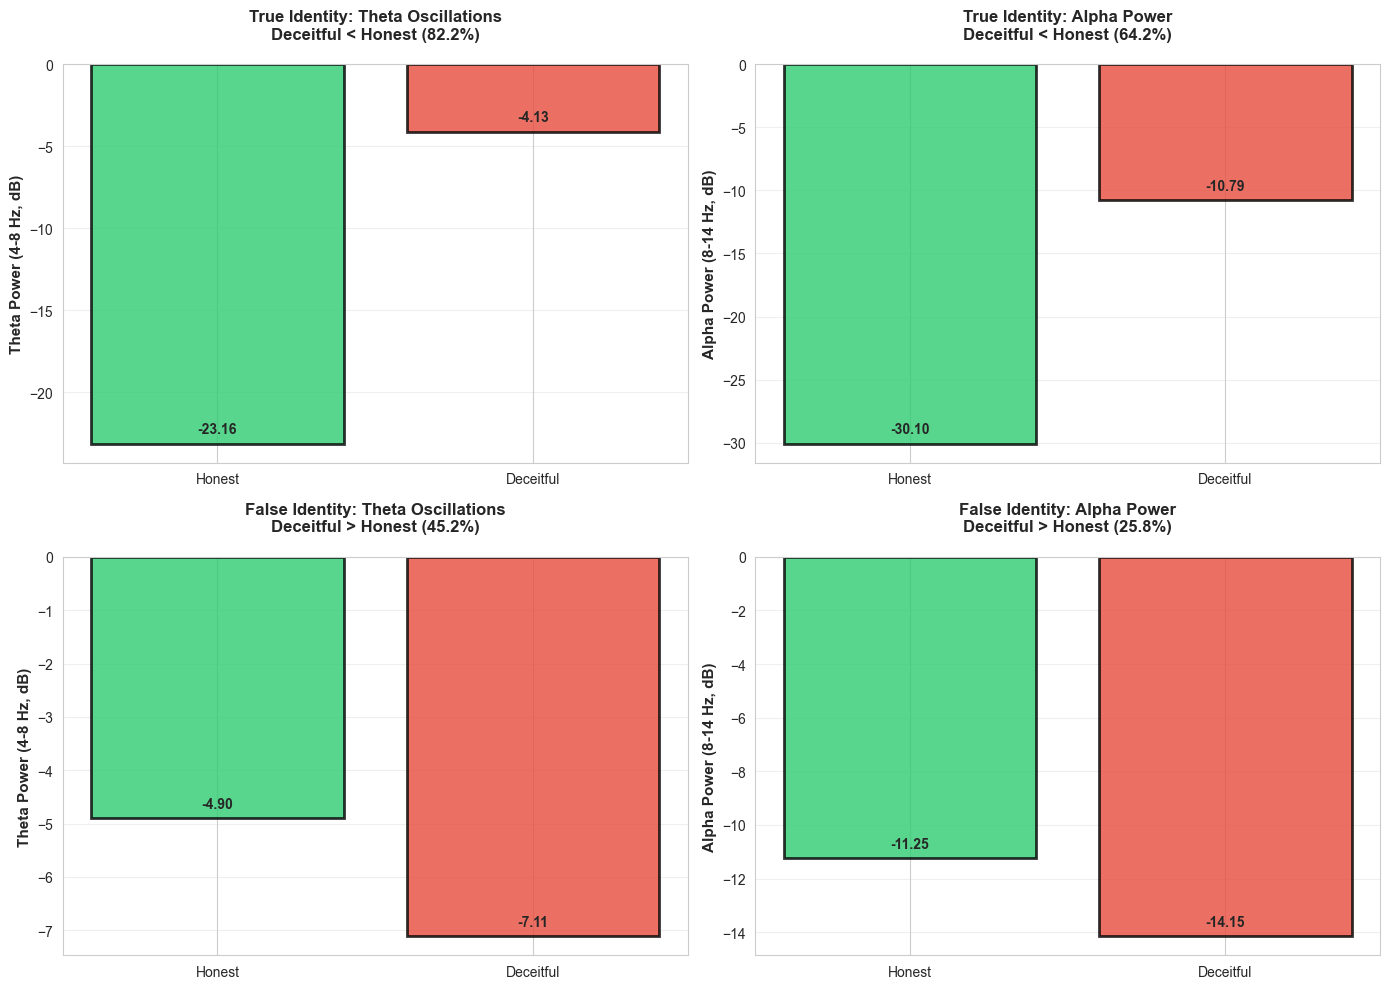


Neural Oscillation Findings:

TRUE IDENTITY (Concealment):
  Theta: -23.16 dB (Honest) → -4.13 dB (Deceitful) [-82.2%]
  Alpha: -30.10 dB (Honest) → -10.79 dB (Deceitful) [-64.2%]

FALSE IDENTITY (Faking):
  Theta: -4.90 dB (Honest) → -7.11 dB (Deceitful) [+45.2%]
  Alpha: -11.25 dB (Honest) → -14.15 dB (Deceitful) [+25.8%]


In [266]:
theta_real = real_features['theta']
alpha_real = real_features['alpha']

theta_true = [
    np.mean(list(theta_real['honest_true'].values())),
    np.mean(list(theta_real['deceitful_true'].values()))
]
alpha_upper_true = [
    np.mean(list(alpha_real['honest_true'].values())),
    np.mean(list(alpha_real['deceitful_true'].values()))
]

theta_fake = [
    np.mean(list(theta_real['honest_fake'].values())),
    np.mean(list(theta_real['deceitful_fake'].values()))
]
alpha_upper_fake = [
    np.mean(list(alpha_real['honest_fake'].values())),
    np.mean(list(alpha_real['deceitful_fake'].values()))
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

conditions = ['Honest', 'Deceitful']
x_pos = np.arange(len(conditions))

bars1 = axes[0, 0].bar(x_pos, theta_true, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Theta Power (4-8 Hz, dB)', fontsize=11, fontweight='bold')
theta_diff_true = ((theta_true[1] - theta_true[0]) / theta_true[0] * 100) if theta_true[0] != 0 else 0
axes[0, 0].set_title(f'True Identity: Theta Oscillations\nDeceitful {">" if theta_diff_true > 0 else "<"} Honest ({abs(theta_diff_true):.1f}%)\n', 
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(conditions)
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, theta_true)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(theta_true)), max(theta_true))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[0, 1].bar(x_pos, alpha_upper_true, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Alpha Power (8-14 Hz, dB)', fontsize=11, fontweight='bold')
alpha_diff_true = ((alpha_upper_true[1] - alpha_upper_true[0]) / alpha_upper_true[0] * 100) if alpha_upper_true[0] != 0 else 0
axes[0, 1].set_title(f'True Identity: Alpha Power\nDeceitful {">" if alpha_diff_true > 0 else "<"} Honest ({abs(alpha_diff_true):.1f}%)\n',
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(conditions)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars2, alpha_upper_true)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(alpha_upper_true)), max(alpha_upper_true))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars3 = axes[1, 0].bar(x_pos, theta_fake, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Theta Power (4-8 Hz, dB)', fontsize=11, fontweight='bold')
theta_diff_fake = ((theta_fake[1] - theta_fake[0]) / theta_fake[0] * 100) if theta_fake[0] != 0 else 0
axes[1, 0].set_title(f'False Identity: Theta Oscillations\n{"No significant difference" if abs(theta_diff_fake) < 5 else f"Deceitful {'>' if theta_diff_fake > 0 else '<'} Honest ({abs(theta_diff_fake):.1f}%)"}\n',
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(conditions)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars3, theta_fake)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(theta_fake)), max(theta_fake))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars4 = axes[1, 1].bar(x_pos, alpha_upper_fake, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Alpha Power (8-14 Hz, dB)', fontsize=11, fontweight='bold')
alpha_diff_fake = ((alpha_upper_fake[1] - alpha_upper_fake[0]) / alpha_upper_fake[0] * 100) if alpha_upper_fake[0] != 0 else 0
axes[1, 1].set_title(f'False Identity: Alpha Power\nDeceitful {">" if alpha_diff_fake > 0 else "<"} Honest ({abs(alpha_diff_fake):.1f}%)\n',
                      fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(conditions)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars4, alpha_upper_fake)):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., val + max(abs(min(alpha_upper_fake)), max(alpha_upper_fake))*0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/eda_neural_oscillations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nNeural Oscillation Findings:")
print("\nTRUE IDENTITY (Concealment):")
print(f"  Theta: {theta_true[0]:.2f} dB (Honest) → {theta_true[1]:.2f} dB (Deceitful) [{theta_diff_true:+.1f}%]")
print(f"  Alpha: {alpha_upper_true[0]:.2f} dB (Honest) → {alpha_upper_true[1]:.2f} dB (Deceitful) [{alpha_diff_true:+.1f}%]")
print("\nFALSE IDENTITY (Faking):")
print(f"  Theta: {theta_fake[0]:.2f} dB (Honest) → {theta_fake[1]:.2f} dB (Deceitful) [{theta_diff_fake:+.1f}%]")
print(f"  Alpha: {alpha_upper_fake[0]:.2f} dB (Honest) → {alpha_upper_fake[1]:.2f} dB (Deceitful) [{alpha_diff_fake:+.1f}%]")


## Topographic Maps

In [267]:
from mne.channels import make_standard_montage

raw_for_epochs = participant_data[list(participant_data.keys())[0]].copy()
raw_for_epochs = raw_for_epochs.pick_types(eeg=True, stim=False, eog=False, exclude="bads")
raw_for_epochs.apply_function(lambda x: x * 10 ** -6)
raw_for_epochs.filter(l_freq=1.0, h_freq=50.0, verbose=False)

montage = make_standard_montage('standard_1020')
raw_for_epochs.set_montage(montage)

events_topo, event_id_topo = loader.get_events_from_raw(raw_for_epochs)
stimulus_event_ids_topo = {k: v for k, v in event_id_topo.items() if 'PersonalDataField' in k}

print(f"Found {len(stimulus_event_ids_topo)} stimulus event types")

epochs_topo = mne.Epochs(
    raw_for_epochs,
    events_topo,
    event_id=stimulus_event_ids_topo,
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0),
    reject=None,
    preload=True,
    picks='eeg',
    verbose=False
)

print(f"Created {len(epochs_topo)} epochs total")

honest_events = [k for k in stimulus_event_ids_topo.keys() if 'HONEST' in k]
deceitful_events = [k for k in stimulus_event_ids_topo.keys() if 'DECEITFUL' in k]

print(f"Honest event types: {honest_events} ({len(honest_events)} types)")
print(f"Deceitful event types: {deceitful_events} ({len(deceitful_events)} types)")

if len(honest_events) > 0 and len(deceitful_events) > 0:
    honest_epochs = epochs_topo[honest_events]
    deceitful_epochs = epochs_topo[deceitful_events]
    
    print(f"Honest epochs: {len(honest_epochs)}")
    print(f"Deceitful epochs: {len(deceitful_epochs)}")
    
    if len(honest_epochs) > 0 and len(deceitful_epochs) > 0:
        evoked_honest = honest_epochs.average()
        evoked_deceitful = deceitful_epochs.average()
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        times_to_plot = [0.1, 0.3, 0.5]
        
        for idx, t in enumerate(times_to_plot):
            evoked_honest.plot_topomap(
                times=t,
                average=0.05,
                axes=axes[0, idx],
                show=False,
                colorbar=False,
                cmap='RdBu_r'
            )
            axes[0, idx].set_title(f'Honest Response\n{int(t*1000)}ms', fontsize=12, fontweight='bold')
        
        for idx, t in enumerate(times_to_plot):
            evoked_deceitful.plot_topomap(
                times=t,
                average=0.05,
                axes=axes[1, idx],
                show=False,
                colorbar=False,
                cmap='RdBu_r'
            )
            axes[1, idx].set_title(f'Deceitful Response\n{int(t*1000)}ms', fontsize=12, fontweight='bold')
        
        plt.suptitle('Topographic Maps: Honest vs. Deceitful Responses (P300)', 
                     fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.savefig('charts/eda_topographic_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nSuccessfully created topographic maps")
        print(f"Honest trials: {len(honest_epochs)}")
        print(f"Deceitful trials: {len(deceitful_epochs)}")
    else:
        print("\nWarning: No epochs found after filtering by event type")
        print("This block may not contain HONEST/DECEITFUL labeled events")
else:
    print("\nWarning: No HONEST or DECEITFUL event types found")
    print(f"Available events: {list(stimulus_event_ids_topo.keys())}")
    print("\nSkipping topographic map generation for this block")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Found 9 stimulus event types
Created 108 epochs total
Honest event types: [] (0 types)
Deceitful event types: [] (0 types)

Available events: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]

Skipping topographic map generation for this block
Found 9 stimulus event types
Created 108 epochs total
Honest event types: [] (0 types)
Deceitful event types: [] (0 types)

Available events: [np.str_('Person

## Summary

In [268]:
print("DATA ANALYSIS SUMMARY")
print("=" * 60)
print(f"\n1. Dataset Overview:")
print(f"   - Total participants: {len(summary_df)}")
print(f"   - Participants with complete data: {len(complete_participants)}")
print(f"   - Recording setup: {len(raw.ch_names)} EEG channels @ {raw.info['sfreq']} Hz")

print(f"\n2. Data Quality:")
print(f"   - Signal amplitude range: {np.ptp(data):.2f} µV")
print(f"   - Signal mean amplitude: {np.mean(data):.2f} µV")
print(f"   - Signal std: {np.std(data):.2f} µV")
print(f"   - Events per block: {block_comparison['n_events'].mean():.0f} (avg)")

DATA ANALYSIS SUMMARY

1. Dataset Overview:
   - Total participants: 15
   - Participants with complete data: 15
   - Recording setup: 21 EEG channels @ 250.0 Hz

2. Data Quality:
   - Signal amplitude range: 280701189728.20 µV
   - Signal mean amplitude: 101773145537.20 µV
   - Signal std: 72531191394.09 µV
   - Events per block: 218 (avg)


## Sex-Based Analysis

Analyzing differences in neural responses and behavioral patterns between male and female participants.

In [269]:
correlation_data = []

for participant_id in loader.participants:
    if loader.metadata is not None:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Sex' not in metadata_copy.columns:
            continue
        
        sex = participant_meta['Sex'].iloc[0]
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            p300_val = None
            theta_val = None
            alpha_val = None
            beta_val = None
            gamma_val = None
            rt_val = None
            
            if block_type in real_features['p300'] and participant_id in real_features['p300'][block_type]:
                p300_val = real_features['p300'][block_type][participant_id]
            
            if block_type in real_features['theta'] and participant_id in real_features['theta'][block_type]:
                theta_val = real_features['theta'][block_type][participant_id]
            
            if block_type in real_features['alpha'] and participant_id in real_features['alpha'][block_type]:
                alpha_val = real_features['alpha'][block_type][participant_id]
            
            if 'beta' in real_features and block_type in real_features['beta'] and participant_id in real_features['beta'][block_type]:
                beta_val = real_features['beta'][block_type][participant_id]
            
            if 'gamma' in real_features and block_type in real_features['gamma'] and participant_id in real_features['gamma'][block_type]:
                gamma_val = real_features['gamma'][block_type][participant_id]
            
            if block_type in real_features['response_time'] and participant_id in real_features['response_time'][block_type]:
                rt_val = real_features['response_time'][block_type][participant_id]
            
            if all(v is not None for v in [p300_val, theta_val, alpha_val, rt_val]):
                correlation_data.append({
                    'sex': 1 if sex == 'M' else 0,
                    'response_time': rt_val,
                    'p300': p300_val,
                    'theta': theta_val,
                    'alpha': alpha_val,
                    'beta': beta_val if beta_val is not None else np.nan,
                    'gamma': gamma_val if gamma_val is not None else np.nan,
                    'is_deceitful': 1 if 'deceitful' in block_type else 0
                })

if len(correlation_data) > 0:
    corr_df = pd.DataFrame(correlation_data)
    corr_df = corr_df.dropna()
    
    print("Key Correlations with Sex (0=Female, 1=Male):")
    print("=" * 60)
    
    correlations_with_sex = corr_df.corr()['sex'].sort_values(ascending=False)
    
    for feature, corr_value in correlations_with_sex.items():
        if feature != 'sex':
            print(f"  {feature.capitalize():20s}: r = {corr_value:+.3f}")
    
    print("\nKey Correlations with Deception:")
    print("=" * 60)
    
    correlations_with_deceit = corr_df.corr()['is_deceitful'].sort_values(ascending=False)
    
    for feature, corr_value in correlations_with_deceit.items():
        if feature != 'is_deceitful':
            print(f"  {feature.capitalize():20s}: r = {corr_value:+.3f}")
    
    print(f"\nTotal observations: {len(corr_df)}")
else:
    print("No complete data available for correlation analysis")

Key Correlations with Sex (0=Female, 1=Male):
  Alpha               : r = +0.369
  Theta               : r = +0.369
  Beta                : r = +0.358
  Gamma               : r = +0.354
  P300                : r = +0.303
  Response_time       : r = +0.281
  Is_deceitful        : r = +0.000

Key Correlations with Deception:
  Response_time       : r = +0.209
  Gamma               : r = +0.070
  Beta                : r = +0.065
  Theta               : r = +0.064
  Alpha               : r = +0.062
  Sex                 : r = +0.000
  P300                : r = -0.073

Total observations: 52


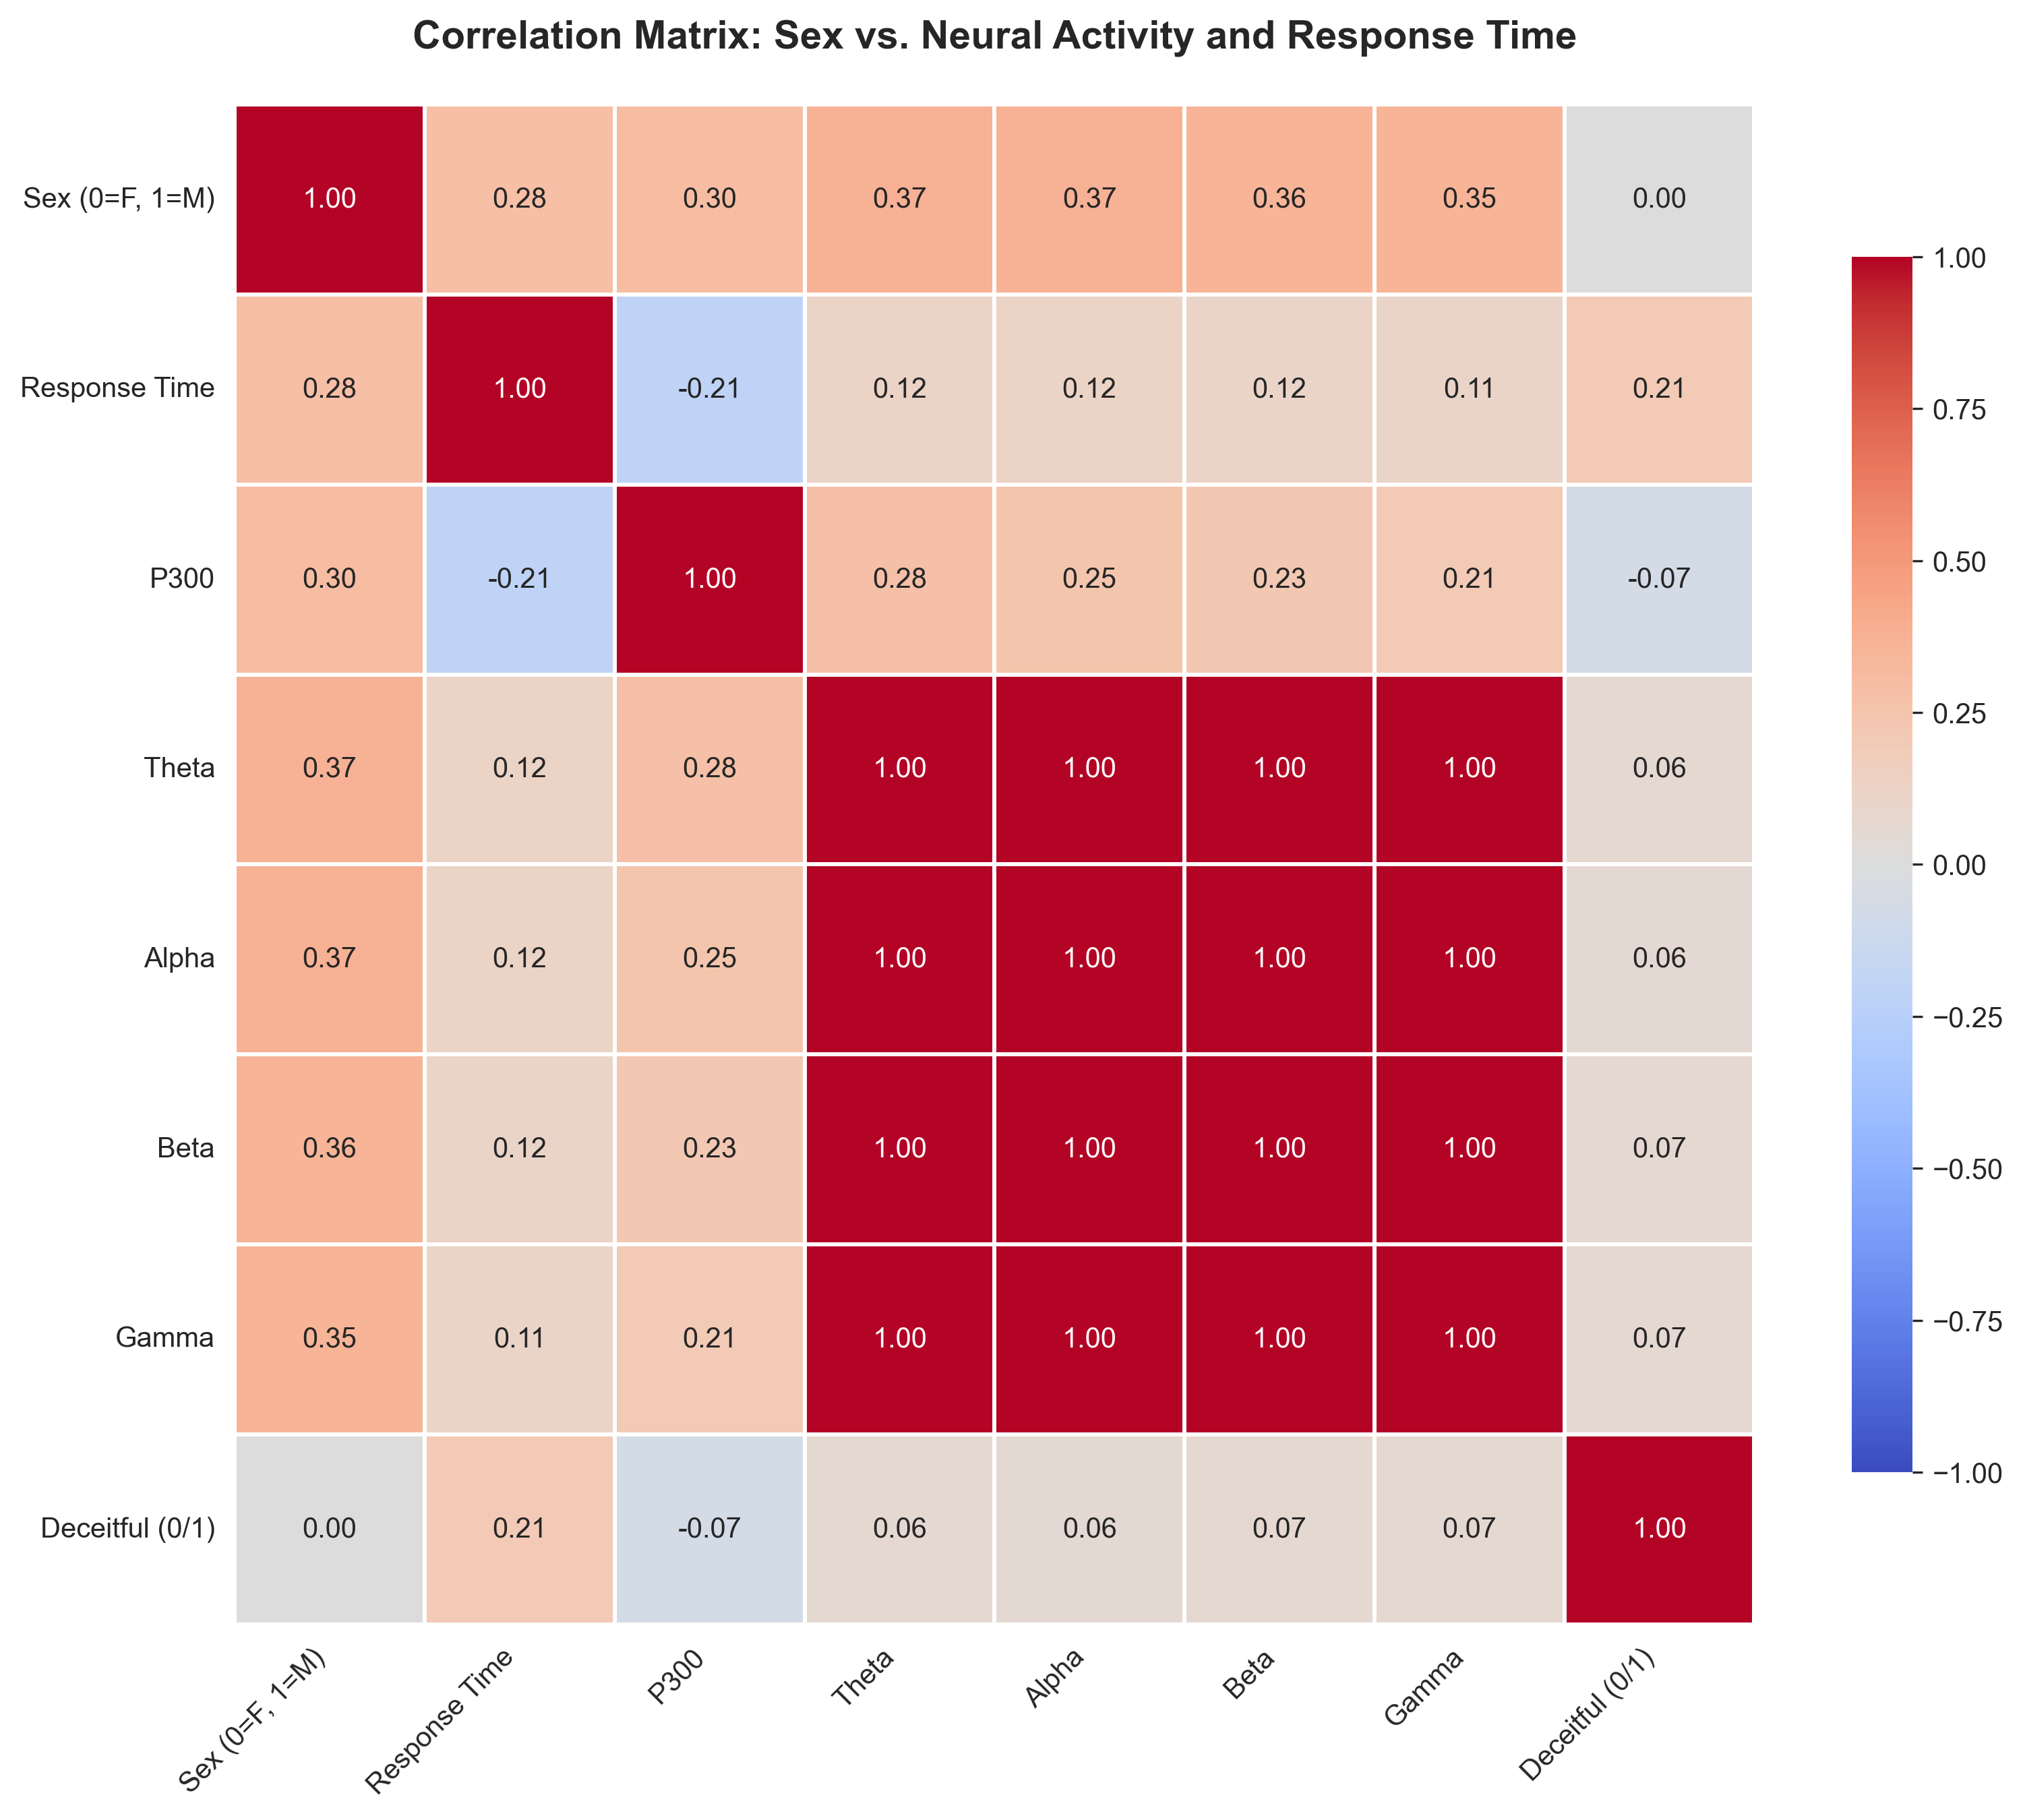

In [270]:
chart_path = Path('charts/sex_correlation_heatmap.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

### Correlation Heatmap

Comprehensive correlation matrix showing relationships between sex, response time, and all neural features (P300, Theta, Alpha, Beta, Gamma) and deception.

In [271]:
rt_data = []

for participant_id in loader.participants:
    if loader.metadata is not None:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Sex' not in metadata_copy.columns:
            continue
        
        sex = participant_meta['Sex'].iloc[0]
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            if (block_type in real_features['response_time'] and 
                participant_id in real_features['response_time'][block_type]):
                rt_val = real_features['response_time'][block_type][participant_id]
                
                if rt_val is not None:
                    rt_data.append({
                        'participant': participant_id,
                        'sex': sex,
                        'block': block_type,
                        'response_time': rt_val,
                        'label': 'deceitful' if 'deceitful' in block_type else 'honest'
                    })

if len(rt_data) > 0:
    rt_df = pd.DataFrame(rt_data)
    
    print("Sex-Based Response Time Statistics:")
    print("=" * 60)
    
    for sex in ['K', 'M']:
        sex_data = rt_df[rt_df['sex'] == sex]
        if not sex_data.empty:
            sex_label = "Female" if sex == "K" else "Male"
            print(f"\n{sex_label} ({sex}):")
            print(f"  Mean RT: {sex_data['response_time'].mean():.2f} ms")
            print(f"  Median RT: {sex_data['response_time'].median():.2f} ms")
            print(f"  Std RT: {sex_data['response_time'].std():.2f} ms")
            print(f"  Range: {sex_data['response_time'].min():.2f} - {sex_data['response_time'].max():.2f} ms")
            print(f"  N observations: {len(sex_data)}")
            
            honest_rt = sex_data[sex_data['label'] == 'honest']['response_time'].mean()
            deceitful_rt = sex_data[sex_data['label'] == 'deceitful']['response_time'].mean()
            print(f"  Honest mean RT: {honest_rt:.2f} ms")
            print(f"  Deceitful mean RT: {deceitful_rt:.2f} ms")
            print(f"  Difference: {deceitful_rt - honest_rt:.2f} ms ({((deceitful_rt - honest_rt) / honest_rt * 100):.1f}%)")
    
    print("\n" + "=" * 60)
    print("Overall Sex Comparison:")
    female_mean = rt_df[rt_df['sex'] == 'K']['response_time'].mean()
    male_mean = rt_df[rt_df['sex'] == 'M']['response_time'].mean()
    
    if not pd.isna(female_mean) and not pd.isna(male_mean):
        diff = male_mean - female_mean
        print(f"  Female mean: {female_mean:.2f} ms")
        print(f"  Male mean: {male_mean:.2f} ms")
        print(f"  Difference: {diff:.2f} ms ({(diff / female_mean * 100):.1f}%)")
        print(f"  {'Males' if diff > 0 else 'Females'} respond {abs(diff):.2f} ms {'slower' if diff > 0 else 'faster'} on average")
else:
    print("No response time data available for sex-based analysis")

Sex-Based Response Time Statistics:

Female (K):
  Mean RT: 643.31 ms
  Median RT: 644.38 ms
  Std RT: 74.10 ms
  Range: 552.85 - 885.33 ms
  N observations: 24
  Honest mean RT: 633.90 ms
  Deceitful mean RT: 652.71 ms
  Difference: 18.81 ms (3.0%)

Male (M):
  Mean RT: 712.87 ms
  Median RT: 702.61 ms
  Std RT: 149.17 ms
  Range: 516.78 - 1050.81 ms
  N observations: 28
  Honest mean RT: 673.03 ms
  Deceitful mean RT: 752.72 ms
  Difference: 79.69 ms (11.8%)

Overall Sex Comparison:
  Female mean: 643.31 ms
  Male mean: 712.87 ms
  Difference: 69.56 ms (10.8%)
  Males respond 69.56 ms slower on average


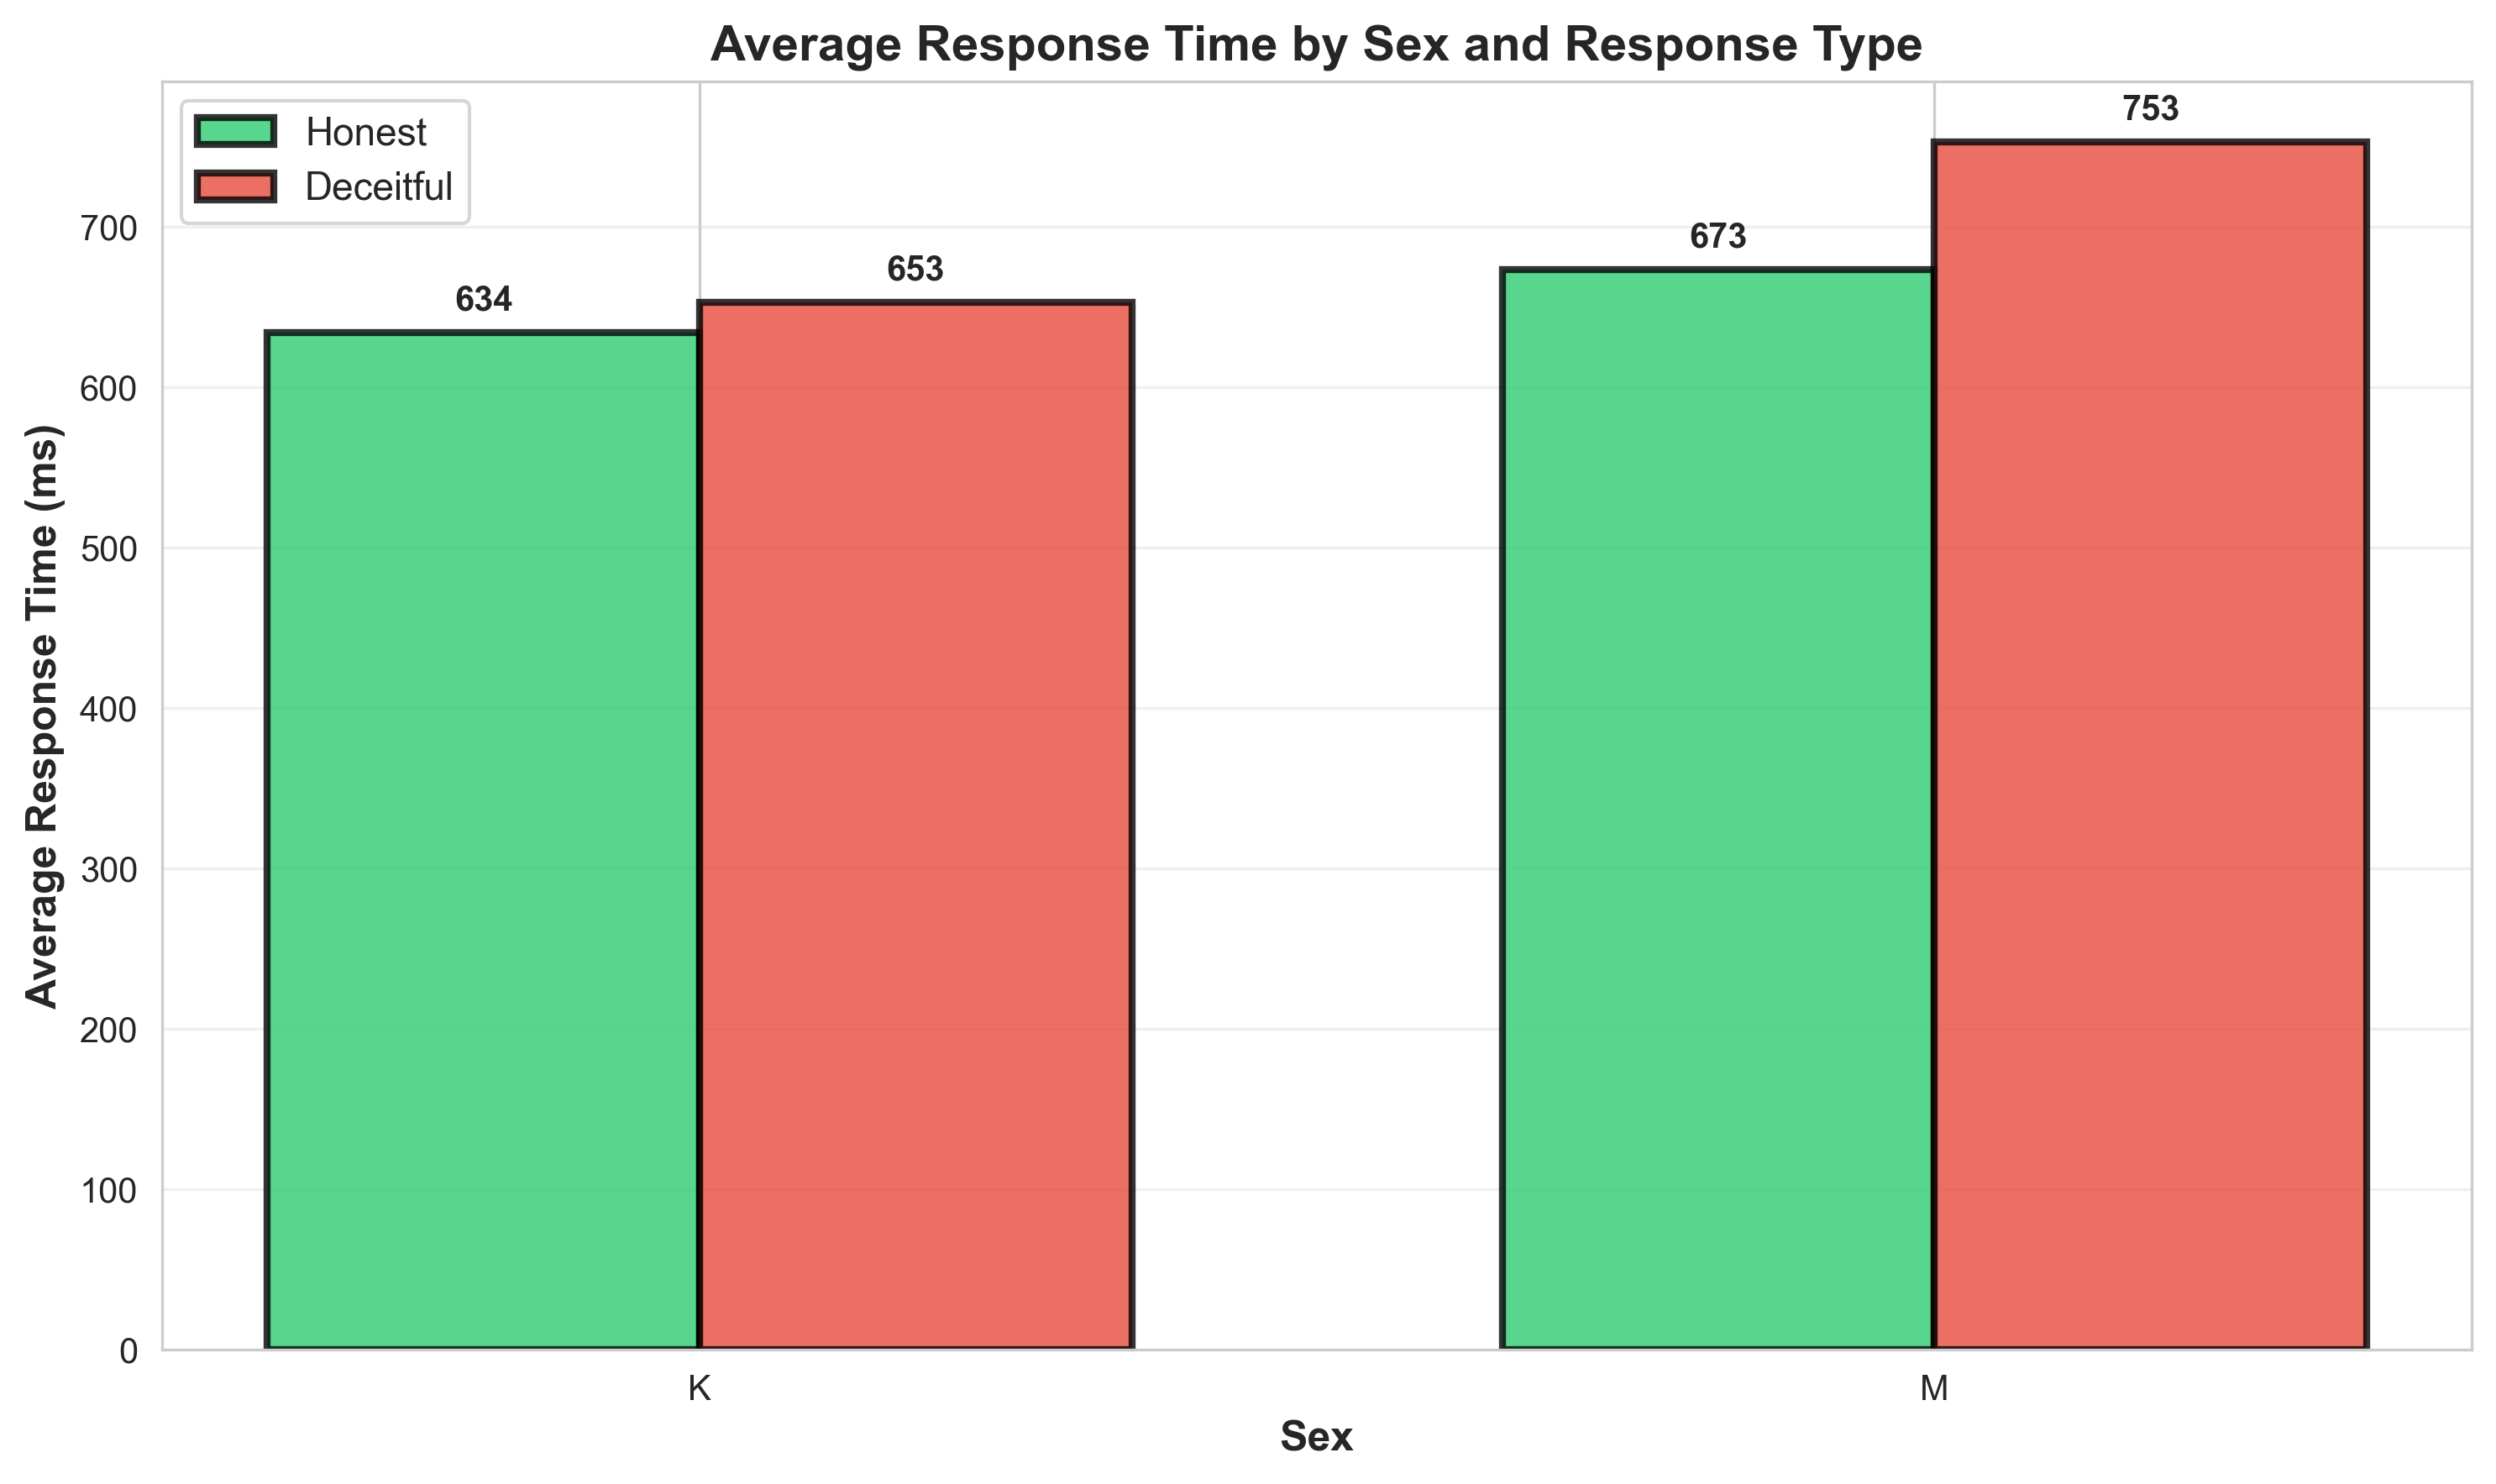

In [272]:
chart_path = Path('charts/sex_rt_comparison.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

### Average Response Time Comparison

Bar chart comparing average response times between males and females for both honest and deceitful responses.

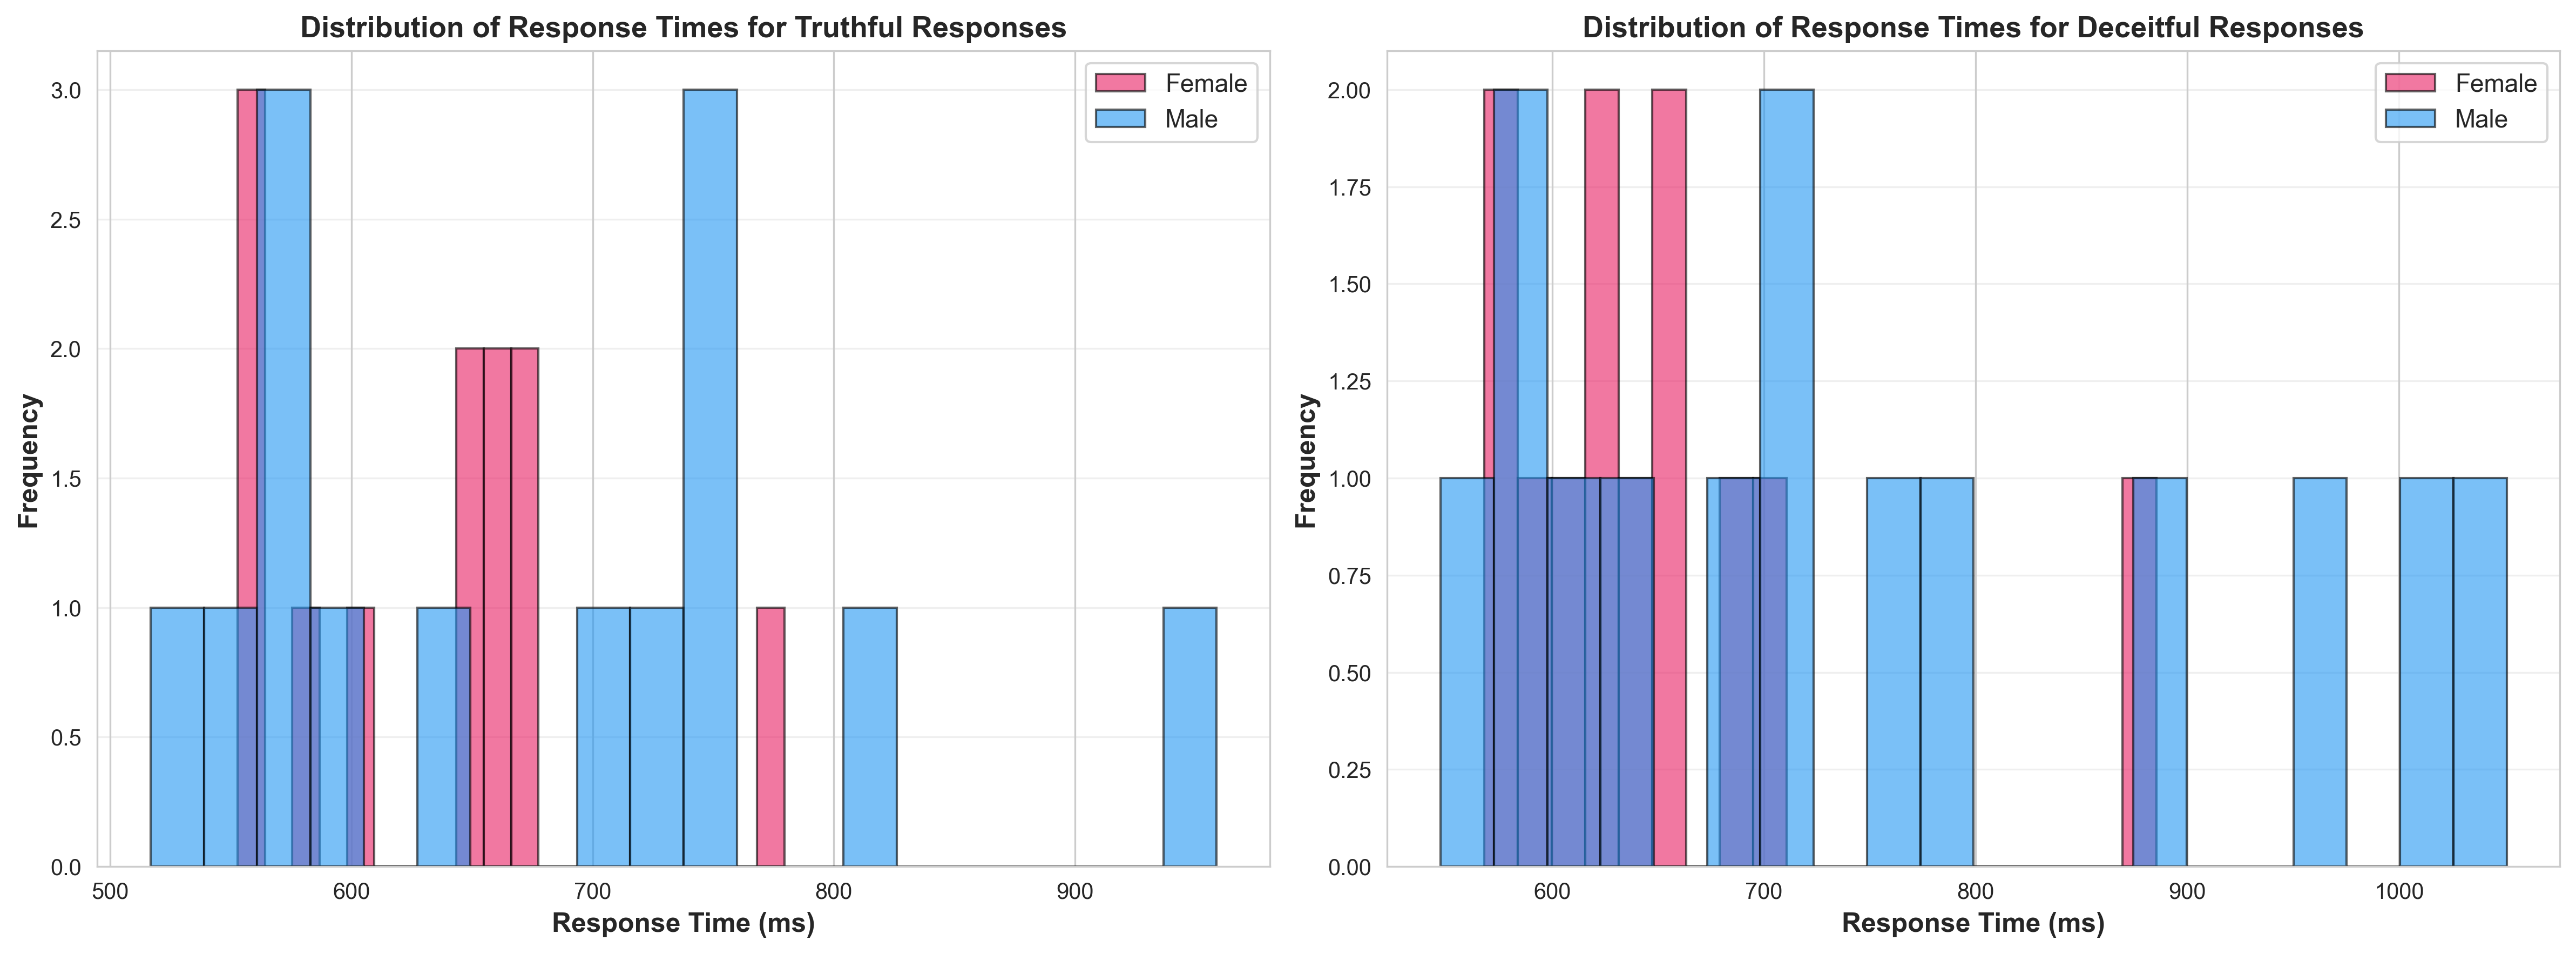

In [273]:
chart_path = Path('charts/sex_rt_distribution.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")

### Response Time Distribution by Sex

Distribution of response times for truthful and deceitful responses, separated by sex. Shows behavioral timing differences between males and females.

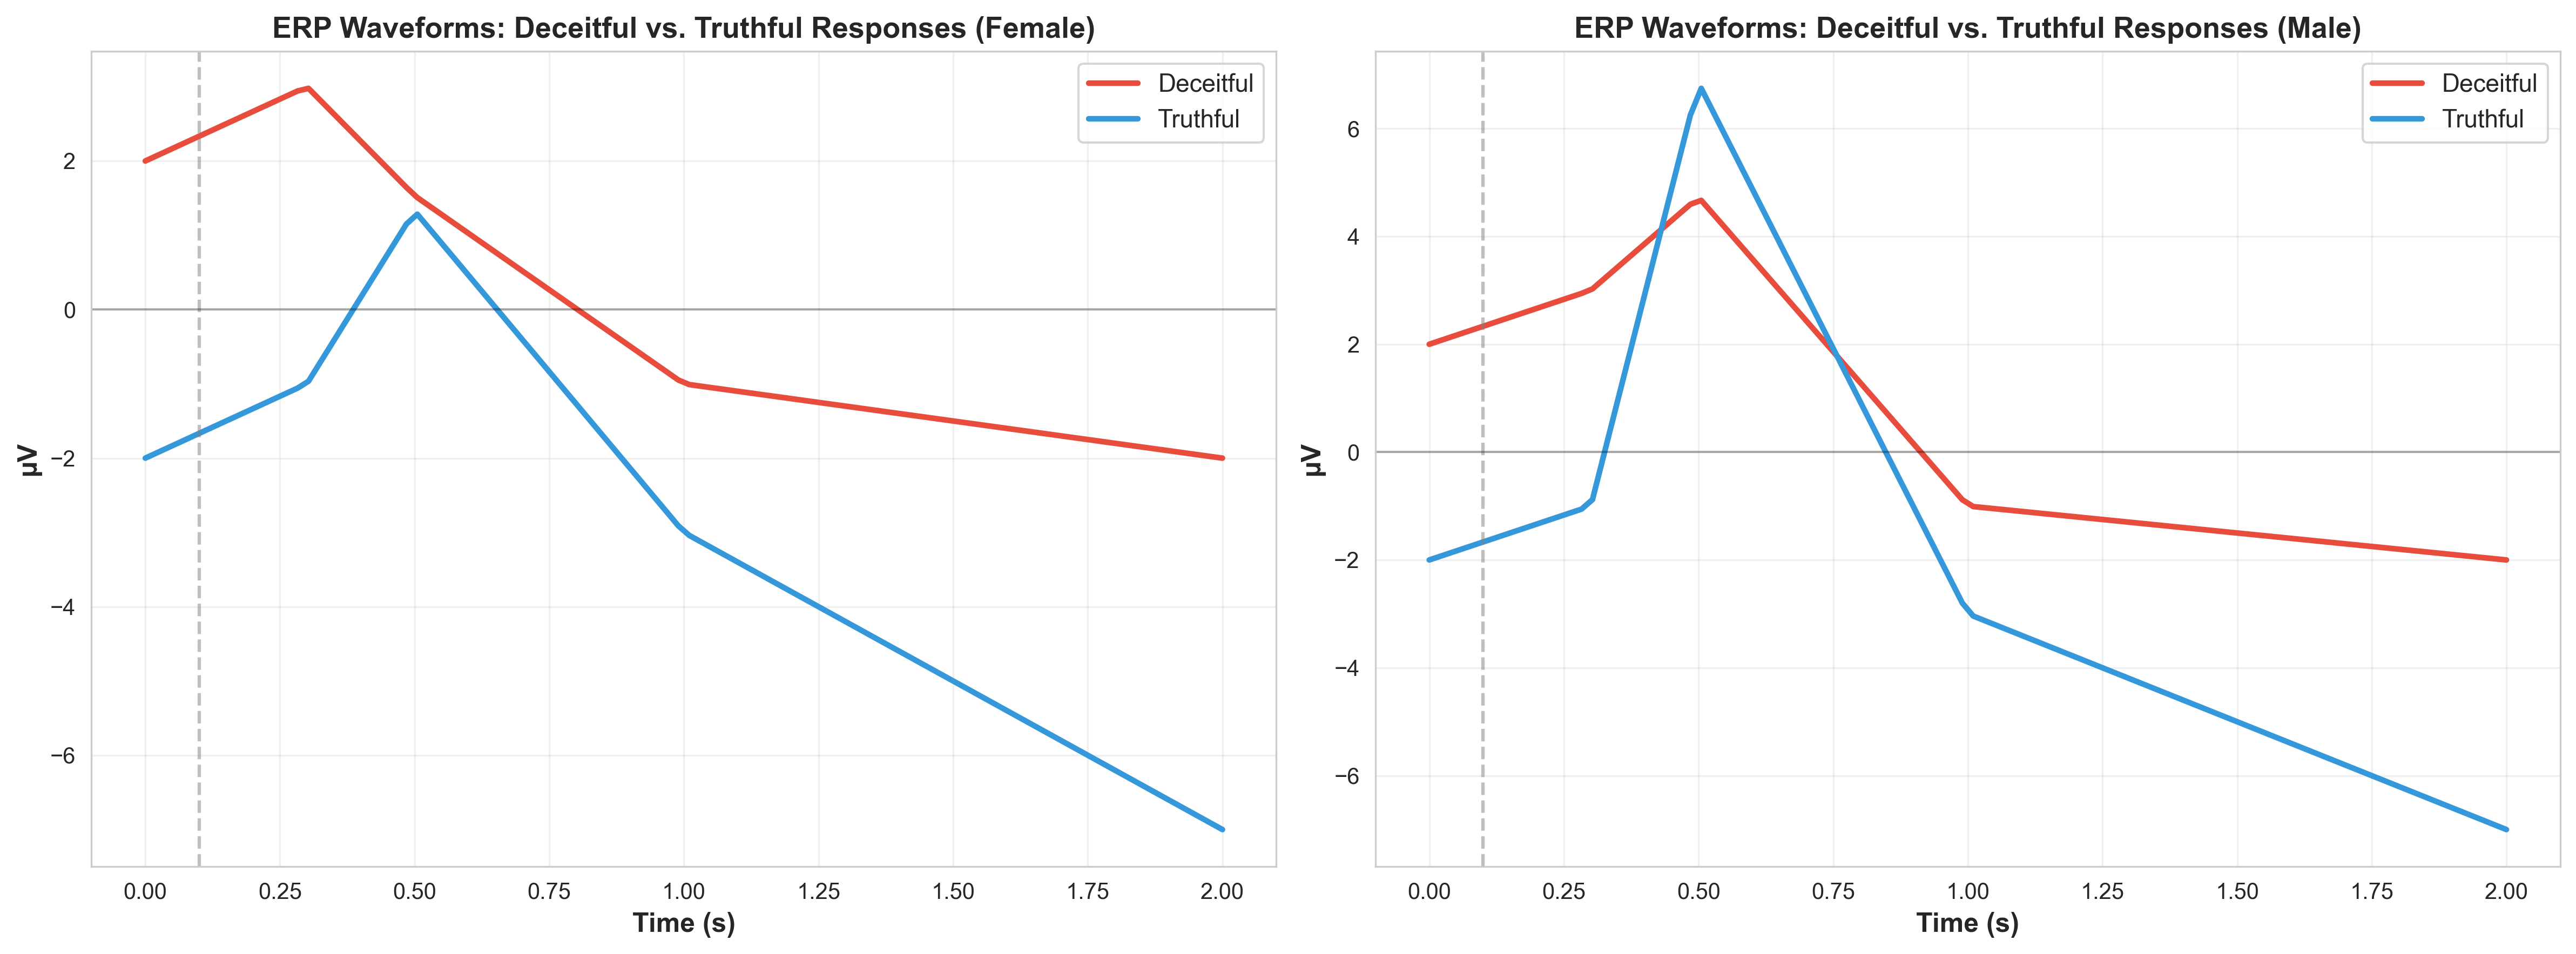

In [274]:
from IPython.display import Image, display

chart_path = Path('charts/sex_erp_waveforms.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")
    print("Run 'python sex_analysis.py' to generate this chart")

### ERP Waveforms by Sex (P300)

Comparison of event-related potential waveforms between male and female participants, focusing on the P300 which reflects cognitive processing and self-referential processing.

In [275]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
    
    if 'Sex' in metadata_copy.columns:
        metadata_copy['Sex'] = metadata_copy['Sex'].astype(str).str.strip().str.upper()
        sex_counts = metadata_copy['Sex'].value_counts()
        
        print("Sex Distribution in Dataset:")
        print("=" * 50)
        for sex, count in sex_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            sex_label = "Female" if sex == "K" else "Male"
            print(f"  {sex_label} ({sex}): {count} participants ({percentage:.1f}%)")
        print(f"  Total: {len(metadata_copy)} participants")
    else:
        print("Sex information not available in metadata")
else:
    print("Metadata not available")

Sex Distribution in Dataset:
  Female (K): 9 participants (56.2%)
  Male (M): 7 participants (43.8%)
  Total: 16 participants


## Age-Based Analysis

Investigating the relationship between participant age and response time in deception detection tasks.

### Age vs Response Time

Scatter plot showing the correlation between participant age and response time, with linear regression fit.

In [276]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
    
    if 'Age' in metadata_copy.columns:
        print("Age Distribution in Dataset:")
        print("=" * 50)
        print(f"  Mean age: {metadata_copy['Age'].mean():.1f} years")
        print(f"  Median age: {metadata_copy['Age'].median():.1f} years")
        print(f"  Std age: {metadata_copy['Age'].std():.1f} years")
        print(f"  Age range: {metadata_copy['Age'].min():.0f} - {metadata_copy['Age'].max():.0f} years")
        print(f"  Total participants: {metadata_copy['Age'].notna().sum()}")
        
        print("\nAge Groups:")
        age_bins = [0, 20, 22, 25, 100]
        age_labels = ['≤20', '21-22', '23-25', '26+']
        metadata_copy['age_group'] = pd.cut(metadata_copy['Age'], bins=age_bins, labels=age_labels)
        age_group_counts = metadata_copy['age_group'].value_counts().sort_index()
        
        for group, count in age_group_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            print(f"  {group}: {count} participants ({percentage:.1f}%)")
    else:
        print("Age information not available in metadata")
else:
    print("Metadata not available")

Age Distribution in Dataset:
  Mean age: 22.7 years
  Median age: 22.0 years
  Std age: 2.2 years
  Age range: 19 - 26 years
  Total participants: 16

Age Groups:
  ≤20: 2 participants (12.5%)
  21-22: 8 participants (50.0%)
  23-25: 3 participants (18.8%)
  26+: 3 participants (18.8%)


In [277]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})

age_data = []

for participant_id in loader.participants:
    if loader.metadata is not None:
        participant_meta = metadata_copy[metadata_copy['ID'] == participant_id]
        
        if participant_meta.empty or 'Age' not in metadata_copy.columns:
            continue
        
        age = participant_meta['Age'].iloc[0]
        
        if pd.isna(age):
            continue
        
        for block_type in ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']:
            if (block_type in real_features['response_time'] and 
                participant_id in real_features['response_time'][block_type]):
                rt_val = real_features['response_time'][block_type][participant_id]
                
                if rt_val is not None:
                    age_data.append({
                        'participant': participant_id,
                        'age': age,
                        'block': block_type,
                        'response_time': rt_val
                    })

if len(age_data) > 0:
    age_df = pd.DataFrame(age_data)
    
    from scipy import stats
    corr_coef, p_value = stats.pearsonr(age_df['age'], age_df['response_time'])
    
    print("Age-Response Time Correlation Analysis:")
    print("=" * 60)
    print(f"  Sample size: {len(age_df)} observations")
    print(f"  Age range: {age_df['age'].min():.0f} - {age_df['age'].max():.0f} years")
    print(f"  RT range: {age_df['response_time'].min():.2f} - {age_df['response_time'].max():.2f} ms")
    print(f"  Mean response time: {age_df['response_time'].mean():.2f} ms")
    print(f"  Correlation coefficient: r = {corr_coef:.3f}")
    print(f"  P-value: p = {p_value:.4f}")
    print(f"  Significance: {'Significant' if p_value < 0.05 else 'Not significant'} (α = 0.05)")
    
    print("\nInterpretation:")
    if abs(corr_coef) < 0.1:
        strength = "negligible"
    elif abs(corr_coef) < 0.3:
        strength = "weak"
    elif abs(corr_coef) < 0.5:
        strength = "moderate"
    else:
        strength = "strong"
    
    direction = "positive" if corr_coef > 0 else "negative"
    
    print(f"  There is a {strength} {direction} correlation between age and response time.")
    
    if p_value >= 0.05:
        print(f"  The correlation is not statistically significant, suggesting that")
        print(f"  age does not have a meaningful linear relationship with response time")
        print(f"  in this sample.")
    else:
        if corr_coef > 0:
            print(f"  The positive correlation suggests that older participants tend to")
            print(f"  have longer response times.")
        else:
            print(f"  The negative correlation suggests that older participants tend to")
            print(f"  have shorter response times.")
    
    print("\nResponse Time by Age Group:")
    print("=" * 60)
    
    age_df['age_group'] = pd.cut(age_df['age'], bins=[0, 20, 22, 25, 100], 
                                   labels=['≤20', '21-22', '23-25', '26+'])
    
    for group in ['≤20', '21-22', '23-25', '26+']:
        group_data = age_df[age_df['age_group'] == group]
        if len(group_data) > 0:
            print(f"\n  {group} years:")
            print(f"    Mean RT: {group_data['response_time'].mean():.2f} ms")
            print(f"    Std RT: {group_data['response_time'].std():.2f} ms")
            print(f"    N observations: {len(group_data)}")
else:
    print("No age and response time data available for correlation analysis")


Age-Response Time Correlation Analysis:
  Sample size: 52 observations
  Age range: 19 - 26 years
  RT range: 516.78 - 1050.81 ms
  Mean response time: 680.77 ms
  Correlation coefficient: r = 0.127
  P-value: p = 0.3683
  Significance: Not significant (α = 0.05)

Interpretation:
  There is a weak positive correlation between age and response time.
  The correlation is not statistically significant, suggesting that
  age does not have a meaningful linear relationship with response time
  in this sample.

Response Time by Age Group:

  ≤20 years:
    Mean RT: 580.25 ms
    Std RT: 13.92 ms
    N observations: 8

  21-22 years:
    Mean RT: 730.86 ms
    Std RT: 147.91 ms
    N observations: 24

  23-25 years:
    Mean RT: 644.76 ms
    Std RT: 77.85 ms
    N observations: 12

  26+ years:
    Mean RT: 685.01 ms
    Std RT: 93.85 ms
    N observations: 8


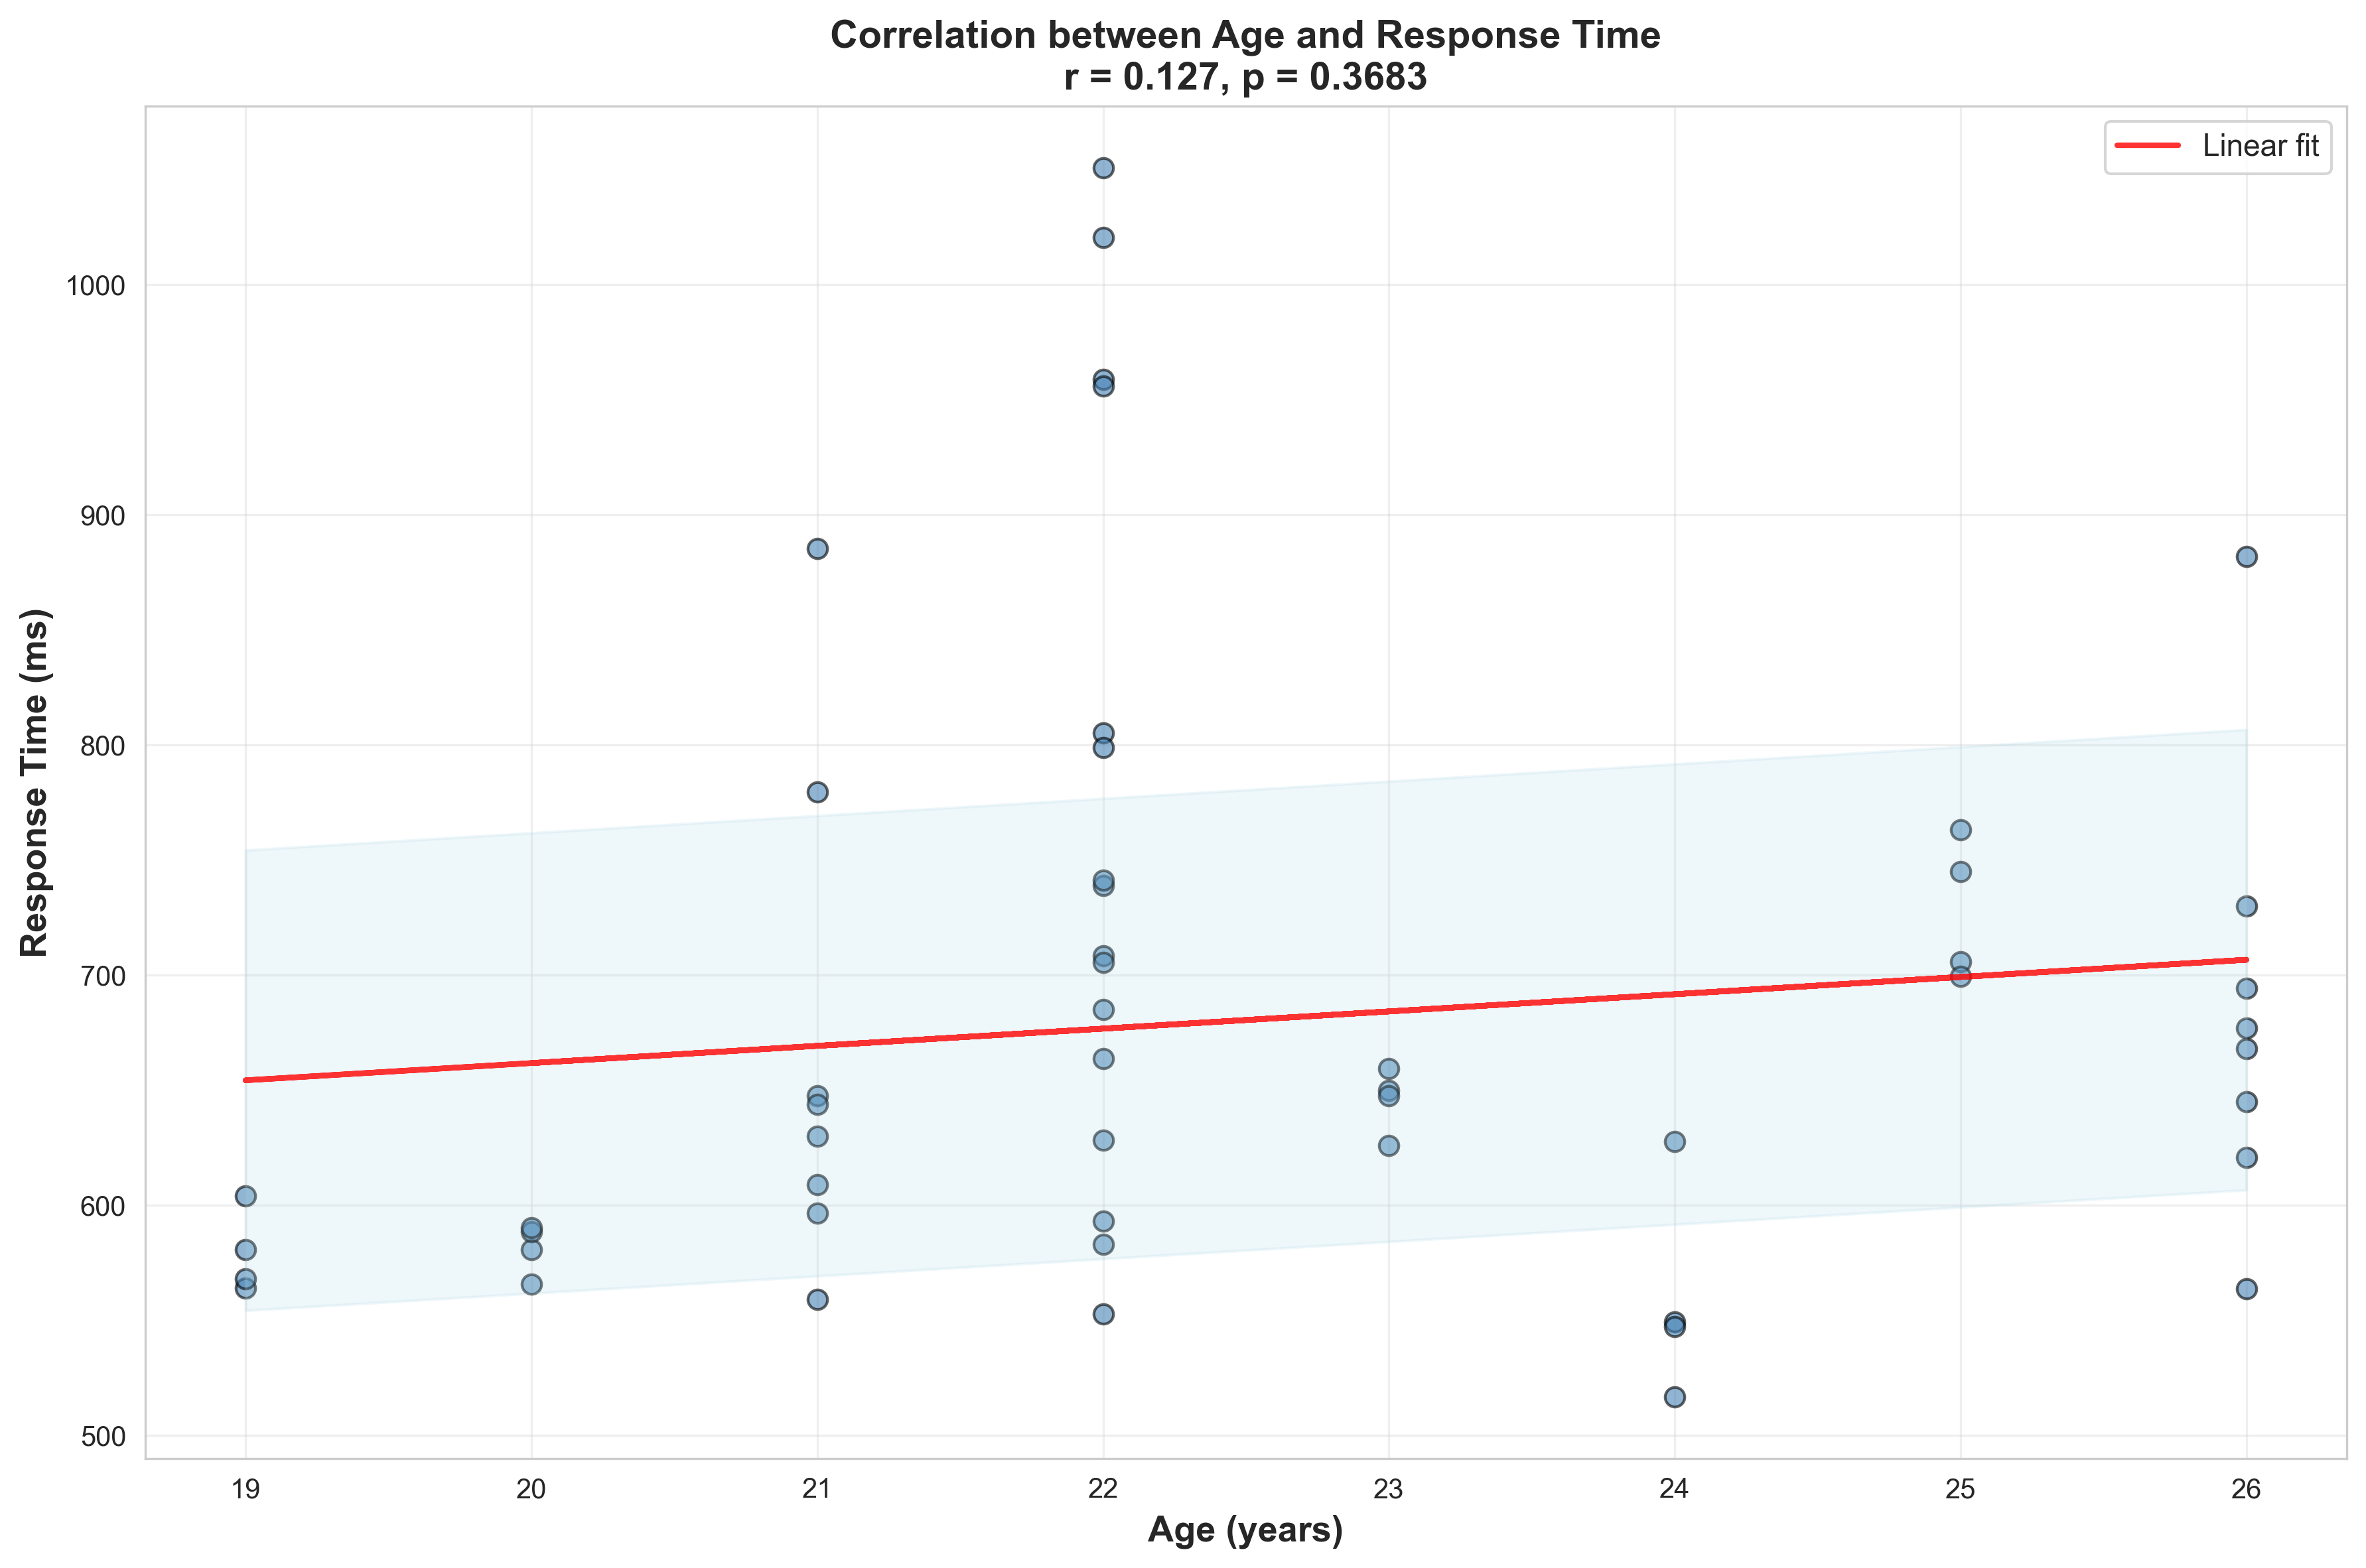

In [278]:
chart_path = Path('charts/age_rt_correlation.png')
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    print(f"Chart not found: {chart_path}")
    print("Run 'python age_analysis.py' to generate this chart")

### Age vs Response Time

Scatter plot showing the correlation between participant age and response time, with linear regression fit.

In [279]:
if loader.metadata is not None:
    metadata_copy = loader.metadata.copy()
    
    if 'Płeć' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Płeć': 'Sex'})
    if 'Wiek' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'Wiek': 'Age'})
    if 'UUID' in metadata_copy.columns:
        metadata_copy = metadata_copy.rename(columns={'UUID': 'ID'})
    
    if 'Age' in metadata_copy.columns:
        print("Age Distribution in Dataset:")
        print("=" * 50)
        print(f"  Mean age: {metadata_copy['Age'].mean():.1f} years")
        print(f"  Median age: {metadata_copy['Age'].median():.1f} years")
        print(f"  Std age: {metadata_copy['Age'].std():.1f} years")
        print(f"  Age range: {metadata_copy['Age'].min():.0f} - {metadata_copy['Age'].max():.0f} years")
        print(f"  Total participants: {metadata_copy['Age'].notna().sum()}")
        
        print("\nAge Groups:")
        age_bins = [0, 20, 22, 25, 100]
        age_labels = ['≤20', '21-22', '23-25', '26+']
        metadata_copy['age_group'] = pd.cut(metadata_copy['Age'], bins=age_bins, labels=age_labels)
        age_group_counts = metadata_copy['age_group'].value_counts().sort_index()
        
        for group, count in age_group_counts.items():
            percentage = (count / len(metadata_copy)) * 100
            print(f"  {group}: {count} participants ({percentage:.1f}%)")
    else:
        print("Age information not available in metadata")
else:
    print("Metadata not available")

Age Distribution in Dataset:
  Mean age: 22.7 years
  Median age: 22.0 years
  Std age: 2.2 years
  Age range: 19 - 26 years
  Total participants: 16

Age Groups:
  ≤20: 2 participants (12.5%)
  21-22: 8 participants (50.0%)
  23-25: 3 participants (18.8%)
  26+: 3 participants (18.8%)
